In [1]:
!pip install --upgrade "jax[cuda12]" equinox diffrax optax

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.8/185.8 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.7/199.7 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 59.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 124.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.4/174.4 MB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.5/85.5 MB 25.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.6/77.6 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 12.7 MB/s eta 0:00:00
  Attempting uninstall: jax-cuda12-pjrt
    Found existing installation: jax-cuda12-pjrt 0.7.2
    Uninstalling jax-cuda12-pjrt-0.7.2:
      Successfully uninstalled jax-cuda12-pjrt-0.7.2
  Attempting uninstall: jax-cuda12-plugin
    Found existing installation: jax-cuda12-plugin 0.7.2


In [ ]:
!pip install --upgrade jax jaxlib equinox diffrax optax

In [ ]:
pip install jax equinox diffrax optax matplotlib

In [2]:
import os
import glob

# Path to the dataset directory
dataset_path = '/content/drive/MyDrive/ap_dataset/'

# List all .mat files in the directory
mat_files = glob.glob(os.path.join(dataset_path, '*.mat'))

print(f"Found {len(mat_files)} .mat files:")
for f in mat_files[:5]: # Print first 5 files as an example
    print(os.path.basename(f))


Found 100 .mat files:
spiral_data_001.mat
spiral_data_002.mat
spiral_data_003.mat
spiral_data_004.mat
spiral_data_005.mat


In [3]:
import scipy.io
import jax.numpy as jnp

first_mat_file = mat_files[0]
data = scipy.io.loadmat(first_mat_file)
print(f"\nContent of {os.path.basename(first_mat_file)}:")
for key, value in data.items():
    if not key.startswith('__'):
        print(f"  Key: {key}, Type: {type(value)}, Shape: {getattr(value, 'shape', 'N/A')}, Dtype: {getattr(value, 'dtype', 'N/A')}")

key_to_convert = None
for k in data.keys():
    if not k.startswith('__') and isinstance(data[k], (list, tuple, dict, object)) and 'spiral_data' in k.lower():
        key_to_convert = k
        break
    elif not k.startswith('__') and isinstance(data[k], (list, tuple, dict, object)) and 'data' in k.lower():
        key_to_convert = k
        break
    elif not k.startswith('__') and isinstance(data[k], (list, tuple, dict, object)) and 'X' in k:
        key_to_convert = k
        break

if key_to_convert:
    numpy_array = data[key_to_convert]
    print(f"\nAttempting to convert key '{key_to_convert}' to JAX array...")
    try:
        jax_array = jnp.asarray(numpy_array)
        print(f"Successfully converted '{key_to_convert}' to JAX array. Shape: {jax_array.shape}, Dtype: {jax_array.dtype}")
        print("First 5 elements (or full array if small):")
        print(jax_array[:5] if jax_array.ndim > 0 and jax_array.shape[0] > 5 else jax_array)
    except Exception as e:
        print(f"Failed to convert '{key_to_convert}' to JAX array: {e}")




Content of spiral_data_001.mat:
  Key: D, Type: <class 'numpy.ndarray'>, Shape: (102, 102), Dtype: float64
  Key: Dfac, Type: <class 'numpy.ndarray'>, Shape: (1, 1), Dtype: float64
  Key: Vsav, Type: <class 'numpy.ndarray'>, Shape: (100, 100, 1496), Dtype: float64
  Key: Wsav, Type: <class 'numpy.ndarray'>, Shape: (100, 100, 1496), Dtype: float64
  Key: a, Type: <class 'numpy.ndarray'>, Shape: (1, 1), Dtype: float64
  Key: b, Type: <class 'numpy.ndarray'>, Shape: (1, 1), Dtype: float64
  Key: dt, Type: <class 'numpy.ndarray'>, Shape: (1, 1), Dtype: float64
  Key: epsi, Type: <class 'numpy.ndarray'>, Shape: (1, 1), Dtype: float64
  Key: h, Type: <class 'numpy.ndarray'>, Shape: (1, 1), Dtype: float64
  Key: k, Type: <class 'numpy.ndarray'>, Shape: (1, 1), Dtype: uint8
  Key: mu1, Type: <class 'numpy.ndarray'>, Shape: (1, 1), Dtype: float64
  Key: mu2, Type: <class 'numpy.ndarray'>, Shape: (1, 1), Dtype: float64
  Key: tCF, Type: <class 'numpy.ndarray'>, Shape: (1, 1), Dtype: uint8
  Key

In [4]:
for k in data.keys():
  if k.startswith('__'):
    continue
  arr = data[k]
  jaxarr= jnp.asarray(arr)
  if jaxarr.shape[0]>5:
    print(f"Key: {k}, Shape: {jaxarr.shape}, Dtype: {jaxarr.dtype}")
    print(jaxarr[:5])
  else:
    print(f"Key: {k}, Shape: {jaxarr.shape}, Dtype: {jaxarr.dtype}")
    print(jaxarr)


Key: D, Shape: (102, 102), Dtype: float32
[[0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15
  0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15
  0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15
  0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15
  0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15
  0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15
  0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15
  0.15 0.15 0.15 0.15]
 [0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15
  0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15
  0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15
  0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15
  0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15
  0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15

In [ ]:
#################################
#Don't need if using saved data.#
#################################

import numpy as np

train_data = []
valid_data = []
test_data = []
for i in range(0, 80):
  data = scipy.io.loadmat(mat_files[i])
  Vsav_temp = data['Vsav']
  Wsav_temp = data['Wsav']
  Vsav_temp = np.transpose(Vsav_temp, (2, 0, 1))
  Wsav_temp = np.transpose(Wsav_temp, (2, 0, 1))
  train_data.append((Vsav_temp, Wsav_temp))
for j in range(80, 90):
  data = scipy.io.loadmat(mat_files[j])
  Vsav_temp = data['Vsav']
  Wsav_temp = data['Wsav']
  Vsav_temp = np.transpose(Vsav_temp, (2, 0, 1))
  Wsav_temp = np.transpose(Wsav_temp, (2, 0, 1))
  valid_data.append((Vsav_temp, Wsav_temp))
for k in range(90, 100):
  data = scipy.io.loadmat(mat_files[k])
  Vsav_temp = data['Vsav']
  Wsav_temp = data['Wsav']
  Vsav_temp = np.transpose(Vsav_temp, (2, 0, 1))
  Wsav_temp = np.transpose(Wsav_temp, (2, 0, 1))
  test_data.append((Vsav_temp, Wsav_temp))
train_data = np.array(train_data)
valid_data = np.array(valid_data)
test_data = np.array(test_data)
print("Train shape: ", train_data.shape)
print("Valid shape: ", valid_data.shape)
print("Test shape: ", test_data.shape)




In [5]:
#We use CPU so far.
def flatten4d(tensor):
  tensor = np.transpose(tensor, (0, 2, 1, 3, 4))
  tensor = tensor.reshape(-1, 2, 100, 100)
  return tensor
new_train = train_data #new_train is the 5D used for neural ODE.
new_test = test_data
new_valid = valid_data
test_data = flatten4d(test_data)
train_data = flatten4d(train_data)
valid_data = flatten4d(valid_data)
print("Saving flat Autoencoder arrays...")
np.save(f'{dataset_path}/train_data_flat.npy', train_data)
np.save(f'{dataset_path}/valid_data_flat.npy', valid_data)
np.save(f'{dataset_path}/test_data_flat.npy', test_data)
print("Train shape: ", train_data.shape)
print("Valid shape: ", valid_data.shape)
print("Test shape: ", test_data.shape)

NameError: name 'train_data' is not defined

In [6]:
import numpy as np

train_data = np.load(dataset_path+'train_data_flat.npy')
valid_data = np.load(dataset_path+'valid_data_flat.npy')
test_data = np.load(dataset_path+'test_data_flat.npy')

In [7]:
new_train = train_data.reshape(80, 1496, 2, 100, 100)
new_train = new_train.transpose(0, 2, 1, 3, 4)
print(new_train.shape)

(80, 2, 1496, 100, 100)


In [ ]:
#Don't need this - slows down JAX.
from torch.utils.data import DataLoader, TensorDataset
import torch

train_dataset = TensorDataset(torch.tensor(train_data))
valid_dataset = TensorDataset(torch.tensor(valid_data))
test_dataset = TensorDataset(torch.tensor(test_data))
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

In [8]:
pip install equinox

In [9]:
import equinox as eqx
import jax

class Encoder(eqx.Module):
  layers:list
  def __init__(self, key):
    keys = jax.random.split(key, 3)
    self.layers = [
        eqx.nn.Conv2d(2, 16, kernel_size=3, stride=2,padding =1, key=keys[0]),
        jax.nn.silu,
        eqx.nn.Conv2d(16, 32, kernel_size=3, stride=2,padding =1, key=keys[1]),
        jax.nn.silu,
        eqx.nn.Conv2d(32, 64, kernel_size=3, stride=2,padding =1, key=keys[2])
    ]
  def __call__(self, x):
    for layer in self.layers:
      x=layer(x)
    return x

class Decoder(eqx.Module):
  layers:list
  def __init__(self, key):
    keys = jax.random.split(key, 3)
    self.layers = [
        eqx.nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1,key=keys[0]),
        jax.nn.silu,
        eqx.nn.ConvTranspose2d(32, 16, kernel_size= 3, stride=2, padding=1, output_padding=1, key=keys[1]),
        jax.nn.silu,
        eqx.nn.ConvTranspose2d(16, 2, kernel_size= 3, stride=2, padding=1, output_padding=1, key=keys[2])
    ]
  def __call__(self, x):
    for layer in self.layers:
      x=layer(x)
    return x



In [10]:
pip install optax

In [11]:
import optax
import equinox as eqx
import jax
import matplotlib.pyplot as plt

encoder_key, decoder_key = jax.random.split(jax.random.PRNGKey(42))
encoder=Encoder(encoder_key)
decoder =Decoder(decoder_key)
start_lr = 1e-3
optimizer = optax.adam(start_lr)
ae_params = (encoder, decoder)

In [ ]:
opt_state = optimizer.init(eqx.filter(ae_params, eqx.is_array))
def autoencoder_loss(params, x, y):
  encoder, decoder = params
  z = jax.vmap(encoder)(x)
  y_hat = jax.vmap(decoder)(z)
  loss = jnp.mean(optax.l2_loss(y_hat, y))
  return loss

num_epochs = 50
step = 0
j = 0
loss = 0
train_steps=[]
valid_steps=[]
train_loss = []
valid_loss = []
batch_size=32
train_data_gpu = jax.device_put(train_data)
valid_data_gpu = jax.device_put(valid_data)

In [ ]:



@eqx.filter_jit
def trainstep(params, opt_state, batch):
  loss, grads = eqx.filter_value_and_grad(autoencoder_loss)(params, batch, batch)
  updates, opt_state = optimizer.update(grads, opt_state, eqx.filter(params, eqx.is_array))
  params=eqx.apply_updates(params, updates)
  return loss, params, opt_state

@eqx.filter_jit
def valid_update(params, batch):
  loss = autoencoder_loss(params, batch, batch)
  return loss

for epoch in range(num_epochs):
  perm = np.random.permutation(train_data_gpu.shape[0])
  for i in range(0, train_data_gpu.shape[0], batch_size):
    batch = train_data_gpu[perm[i:i+batch_size]]
    loss, ae_params, opt_state = trainstep(ae_params, opt_state, batch)
    train_steps.append(step)
    train_loss.append(loss.item())
    if step%100 == 0 and step != 0:
      val = 0
      num = 0
      for j in range(0, valid_data_gpu.shape[0], batch_size):
        interval = min(batch_size, valid_data_gpu.shape[0] - j)
        batch_valid = valid_data_gpu[j:j+interval]
        val += valid_update(ae_params, batch_valid).item()
        num += 1
      val = val/num
      valid_loss.append(val)
      valid_steps.append(step)
      print(f"Epoch {epoch}, Step {step}, Training Loss: {loss.item()}, Validation Loss: {val}")
    step+=1



t_steps = np.array(train_steps)
t_loss = np.array(train_loss)
v_steps = np.array(valid_steps)
v_loss = np.array(valid_loss)

plt.figure(figsize=(10, 5))
plt.plot(t_steps, t_loss, label='Training Loss')
plt.plot(v_steps, v_loss, label='Validation Loss')
plt.yscale('log')




NameError: name 'num_epochs' is not defined

In [12]:
save_path = dataset_path + "cardiac_encoder.eqx"
save_path2 = data
eqx.tree_serialise_leaves(save_path, ae_params)

In [13]:
key = jax.random.PRNGKey(0)

key_enc, key_dec = jax.random.split(key, 2)
empty_encoder = Encoder(key_enc)
empty_decoder = Decoder(key_dec)
empty_skeleton = (empty_encoder, empty_decoder)


loaded_encoder, loaded_decoder = eqx.tree_deserialise_leaves(
    dataset_path + "cardiac_encoder.eqx",
    empty_skeleton
)

In [24]:
trained_encoder, trained_decoder = loaded_encoder, loaded_decoder
activity_levels = jnp.max(valid_data_gpu[:, 0, :, :], axis=(1, 2))
best_idx = jnp.argmax(activity_levels).item()
sample_batch = valid_data_gpu[best_idx:best_idx+1]
z = jax.vmap(trained_encoder)(sample_batch)
reconstruction = jax.vmap(trained_decoder)(z)
orig_img = np.array(sample_batch[0, 0])
recon_img = np.array(reconstruction[0, 0])
error_map = np.abs(orig_img - recon_img)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
im0 = axes[0].imshow(orig_img, cmap='magma', vmin=orig_img.min(), vmax=orig_img.max())
axes[0].set_title('Original Wavefront (Ground Truth)', fontweight='bold')
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)
im1 = axes[1].imshow(recon_img, cmap='magma', vmin=recon_img.min(), vmax=recon_img.max())
axes[1].set_title('Reconstructed (Autoencoder)', fontweight='bold')
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
im2 = axes[2].imshow(error_map, cmap='Reds')
axes[2].set_title('Absolute Error Map', fontweight='bold')
fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

NameError: name 'valid_data_gpu' is not defined

Index 3596 | Max Pixel Error: 0.0246


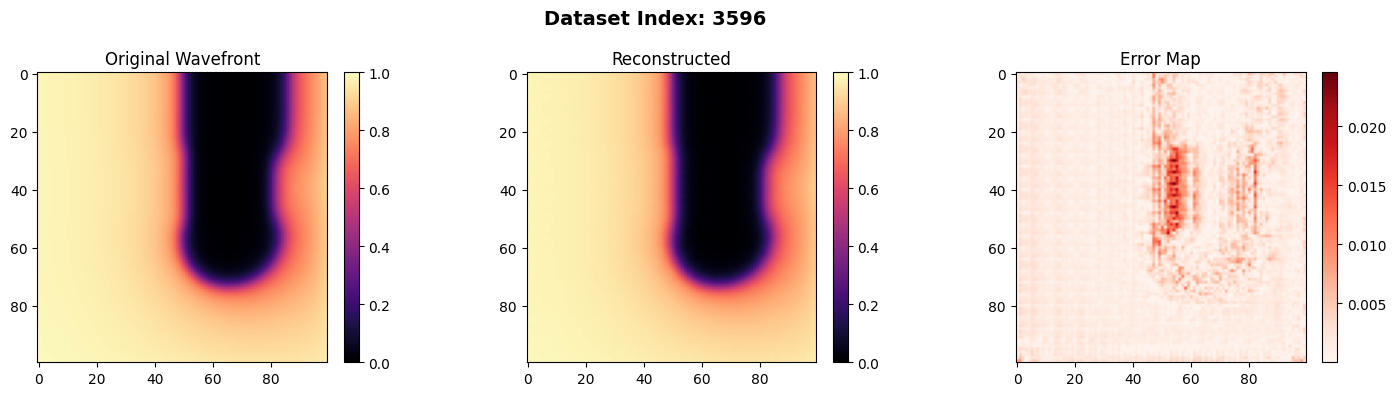

Index 9480 | Max Pixel Error: 0.0316


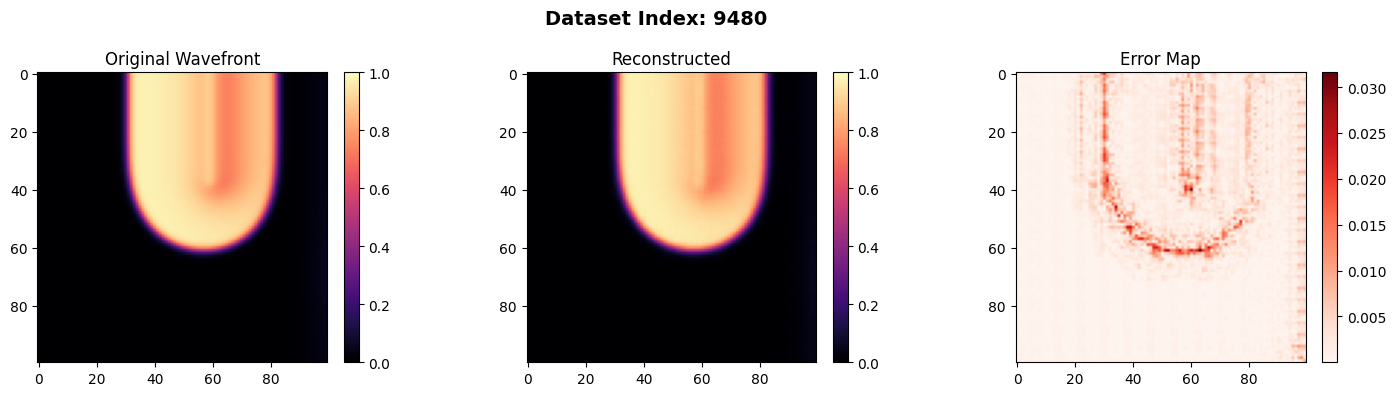

Index 9570 | Max Pixel Error: 0.1392


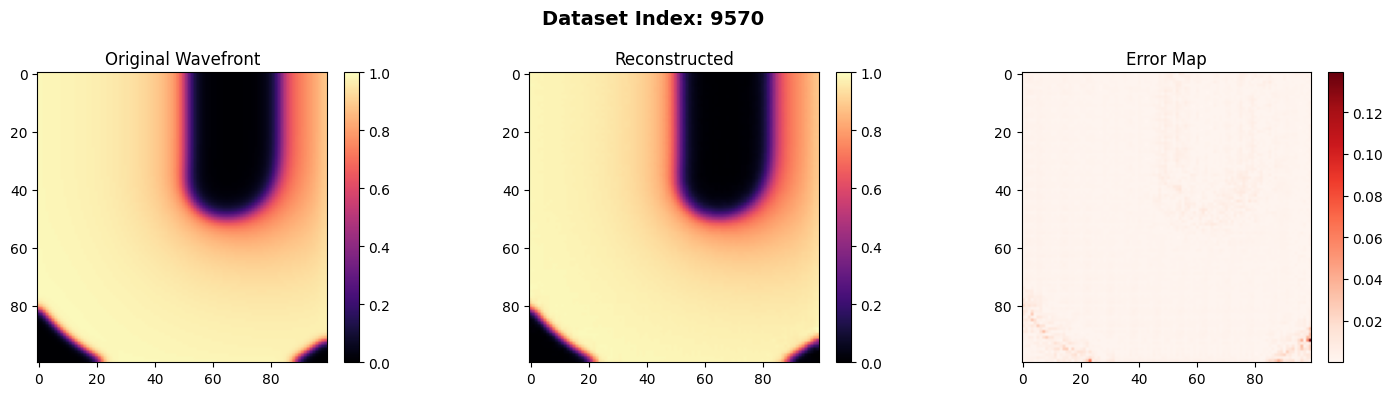

Index 844 | Max Pixel Error: 0.0058


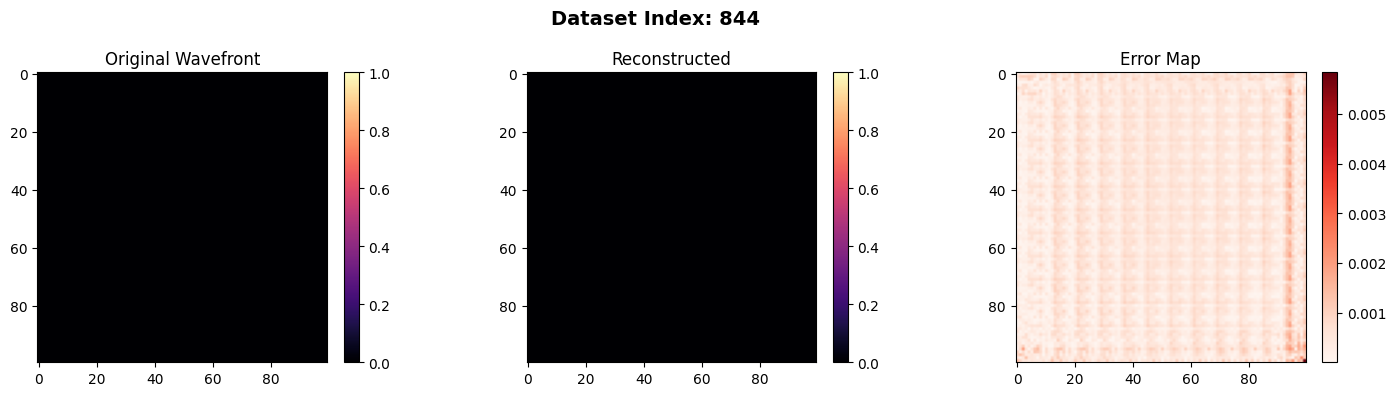

Index 6587 | Max Pixel Error: 0.0060


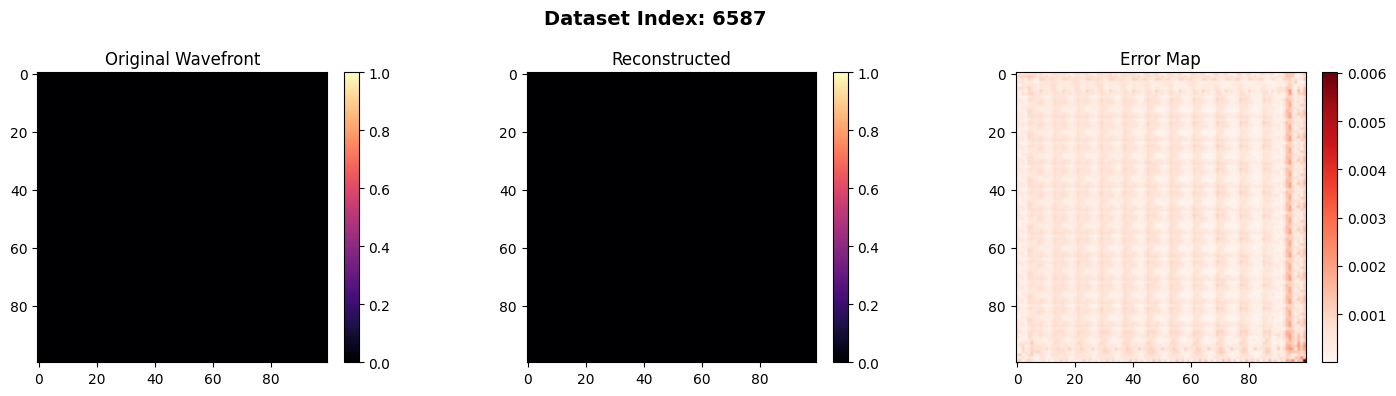

Index 4598 | Max Pixel Error: 0.0136


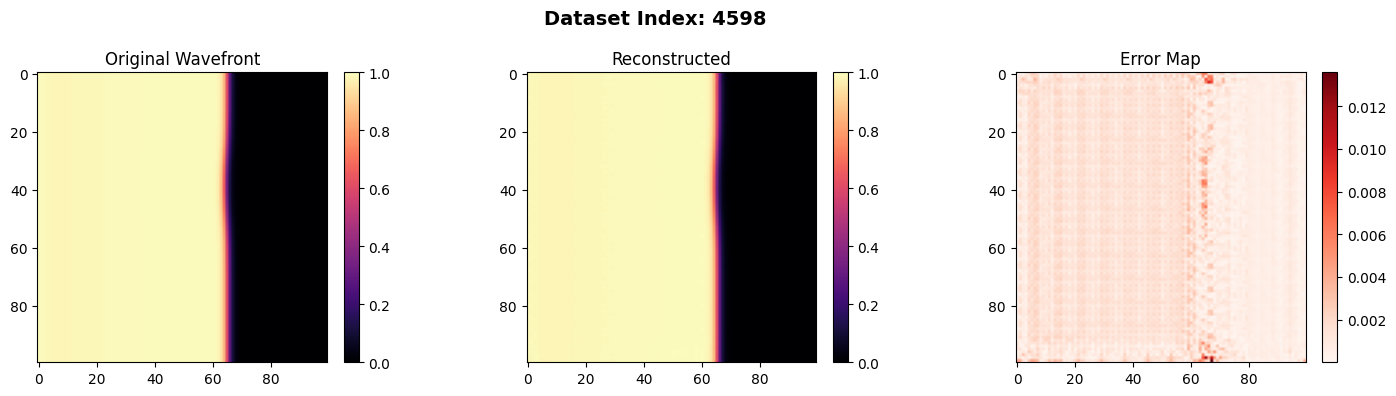

Index 7312 | Max Pixel Error: 0.0035


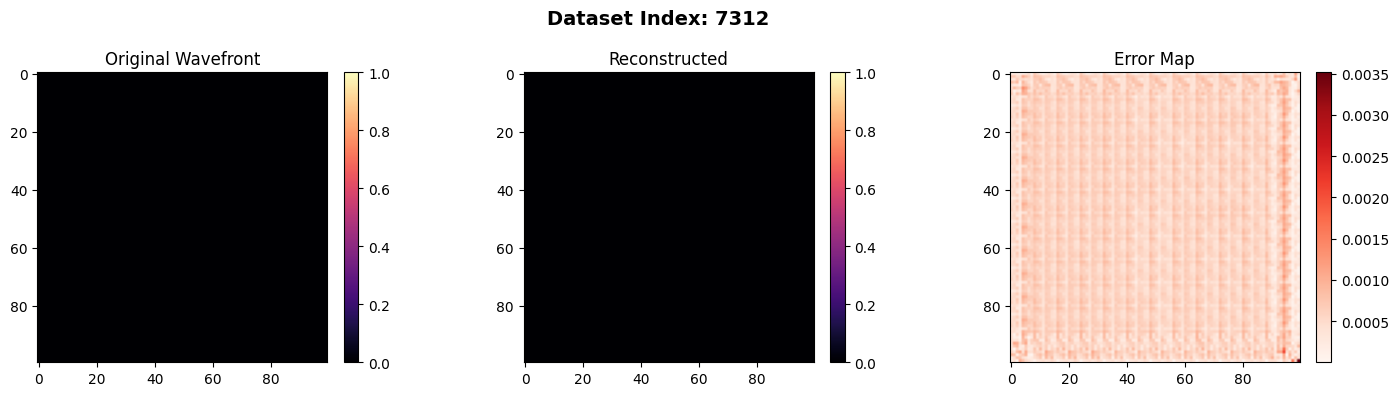

Index 4035 | Max Pixel Error: 0.0045


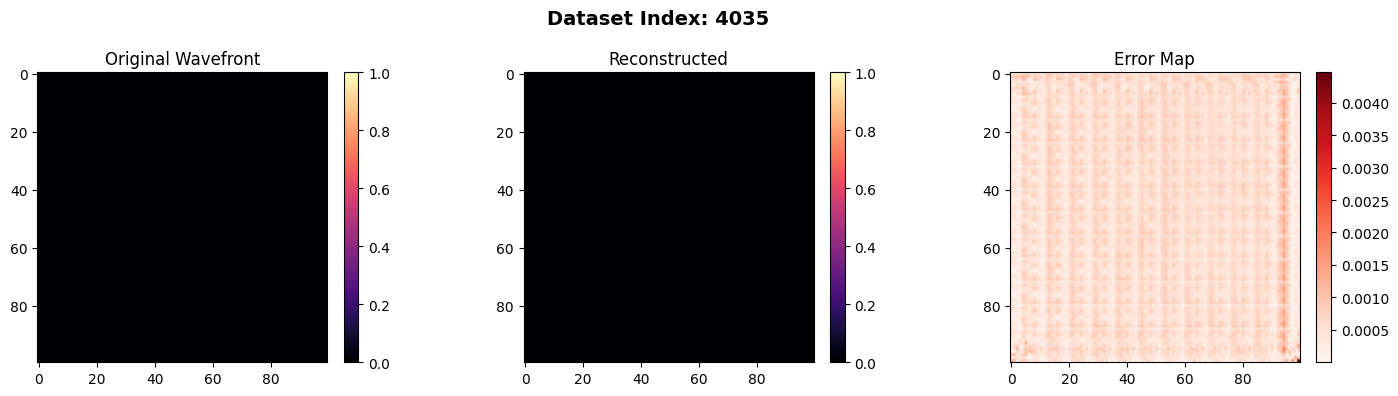

Index 7719 | Max Pixel Error: 0.0079


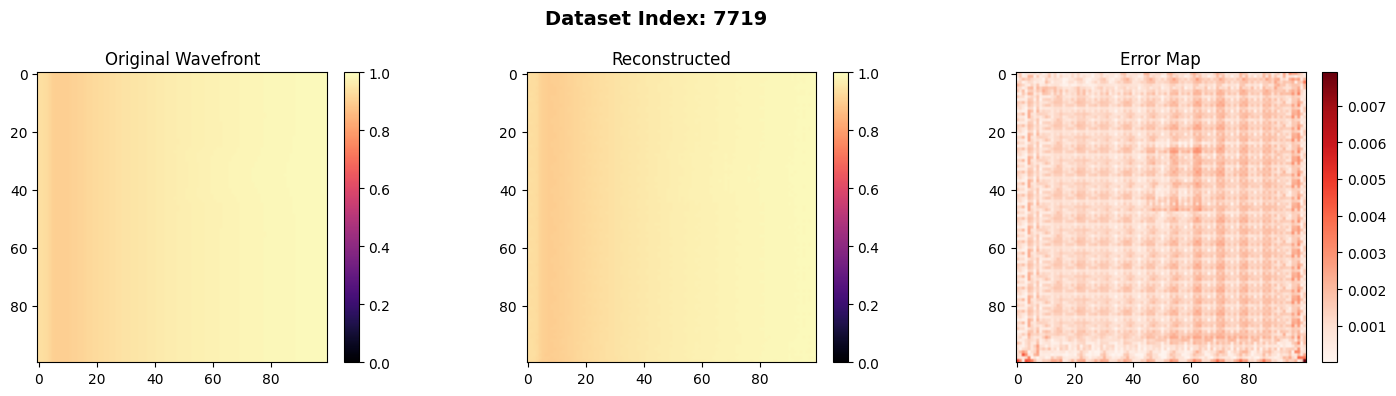

Index 8336 | Max Pixel Error: 0.0043


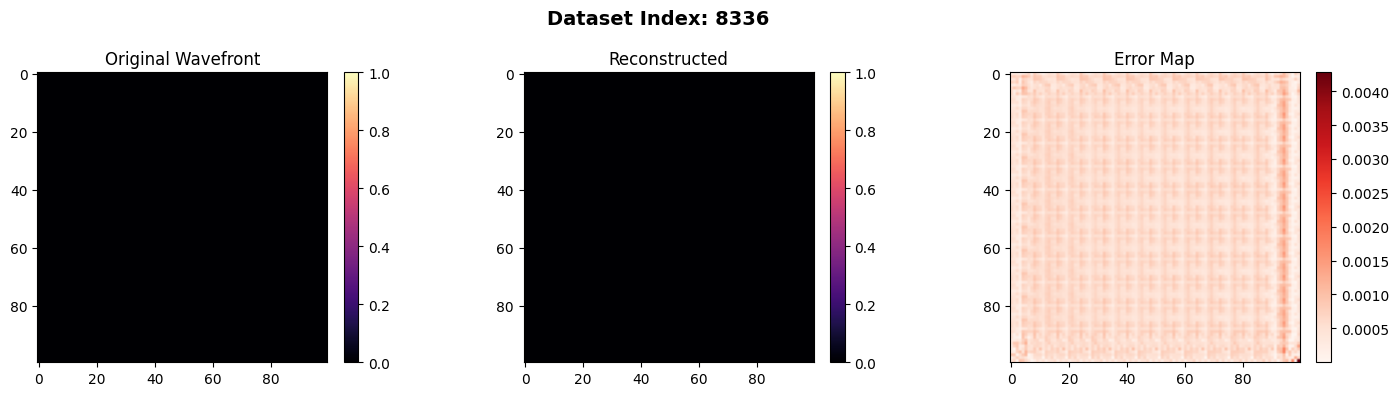

Index 5206 | Max Pixel Error: 0.0049


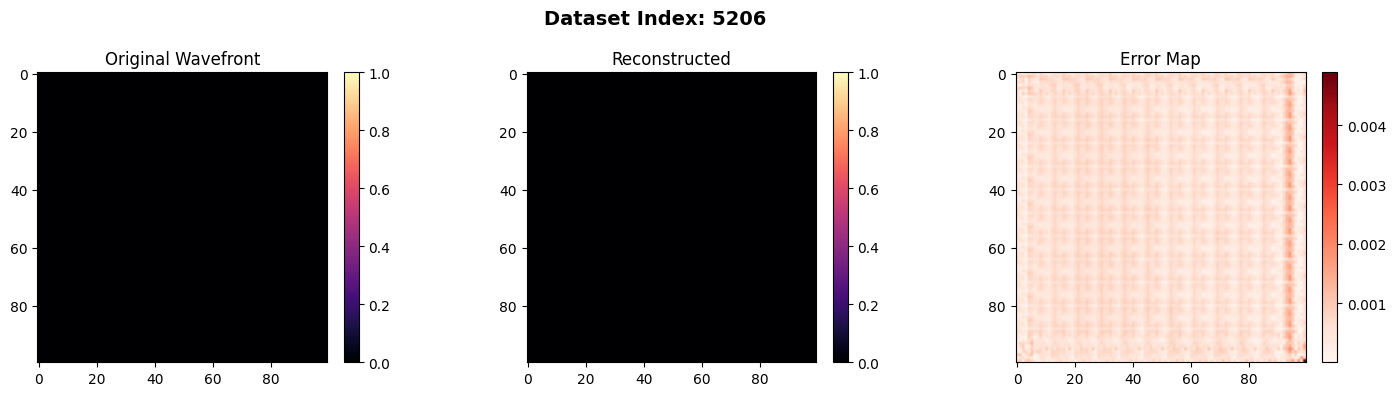

Index 6409 | Max Pixel Error: 0.0067


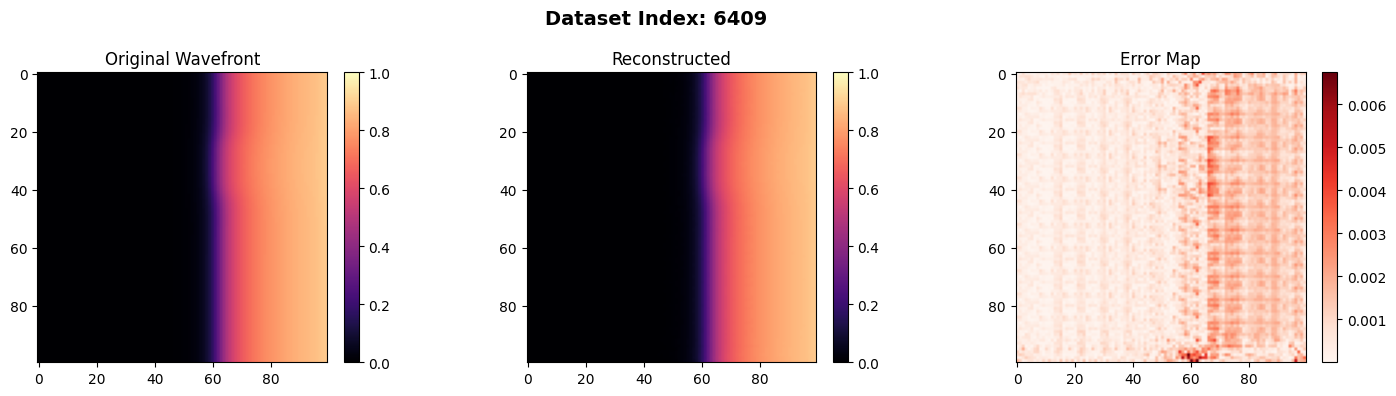

Index 1112 | Max Pixel Error: 0.0042


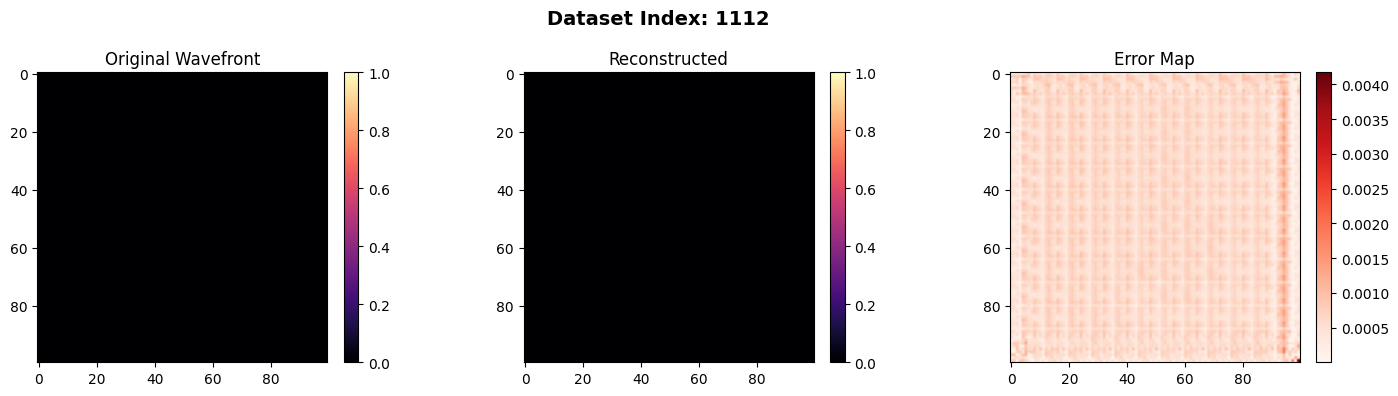

Index 2509 | Max Pixel Error: 0.0050


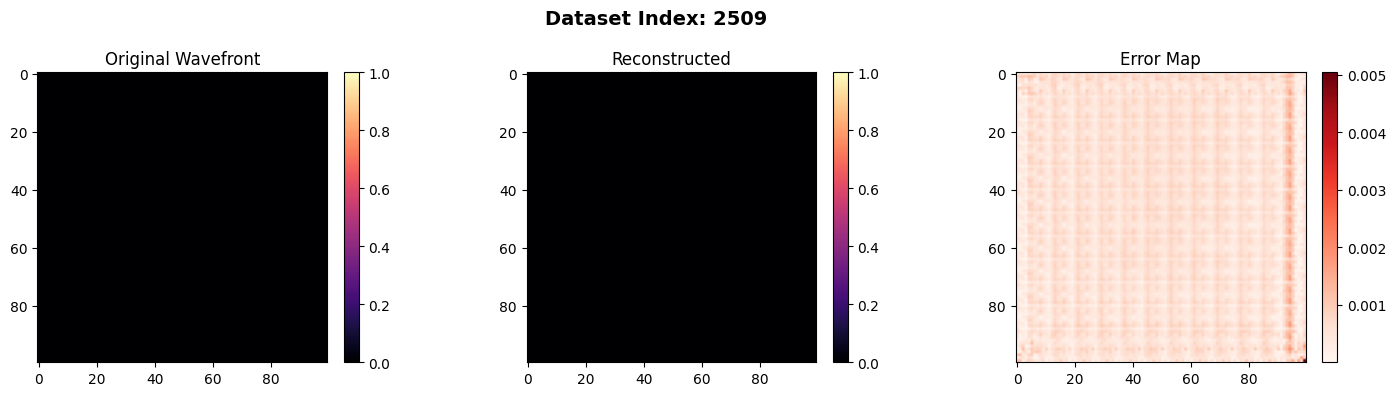

Index 14328 | Max Pixel Error: 0.0231


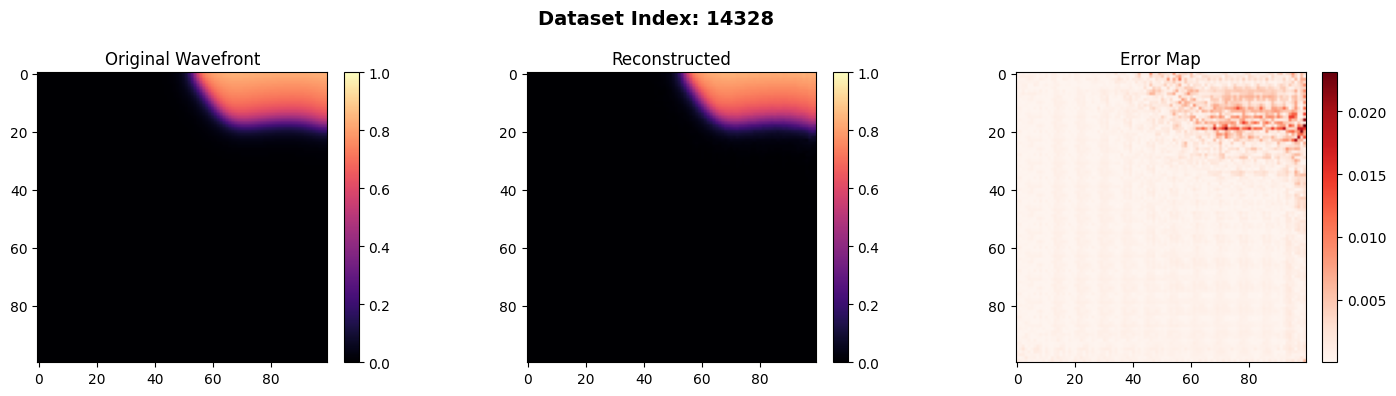

Index 9307 | Max Pixel Error: 0.0158


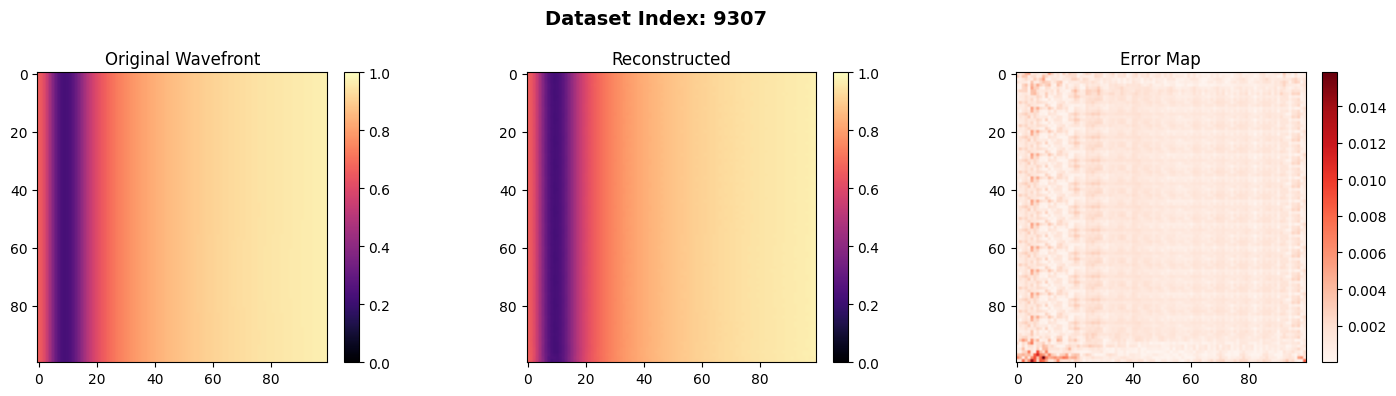

Index 5969 | Max Pixel Error: 0.0034


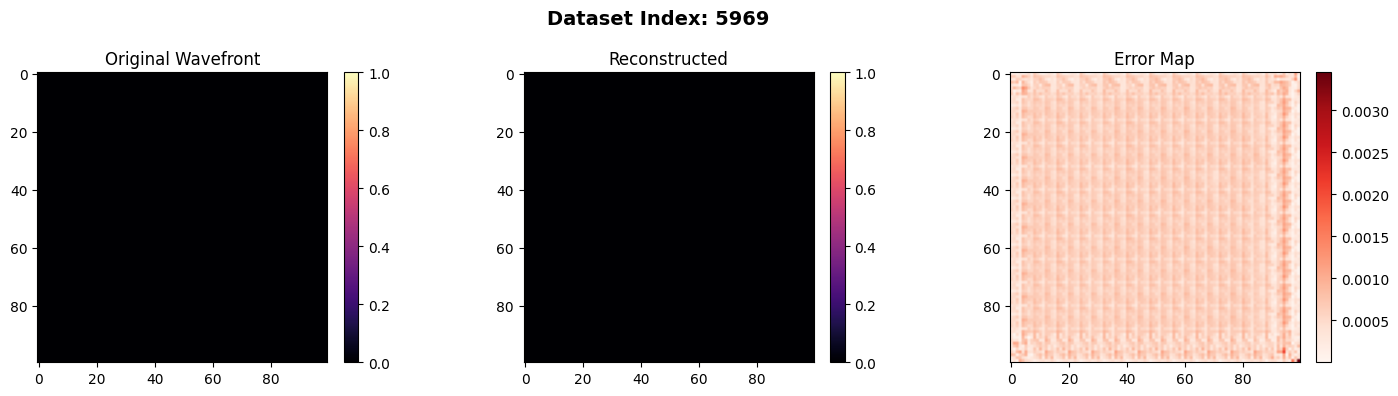

Index 10192 | Max Pixel Error: 0.0041


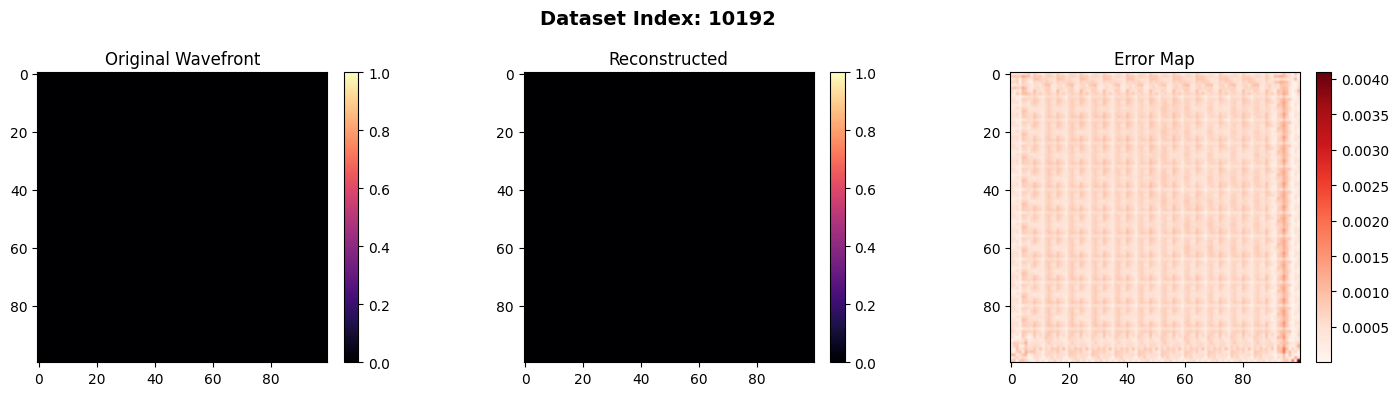

Index 9305 | Max Pixel Error: 0.0154


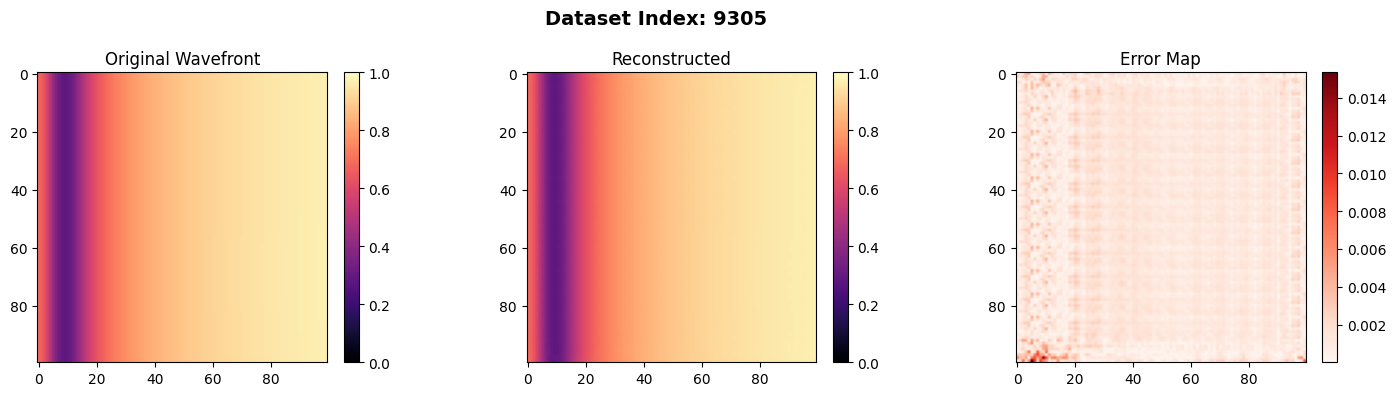

Index 13006 | Max Pixel Error: 0.0047


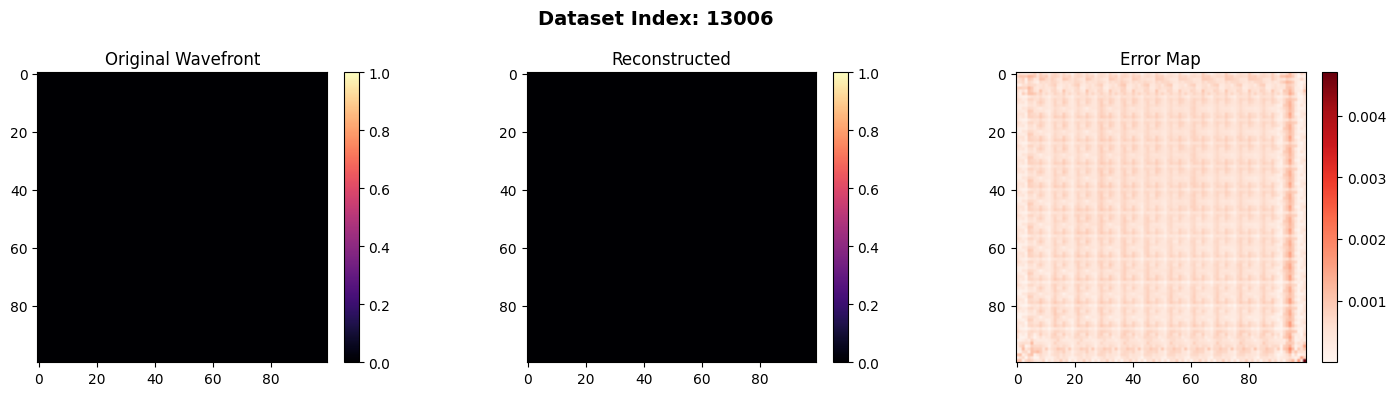

In [ ]:
num_samples = 20
total_val_images = valid_data_gpu.shape[0]
random_indices = np.random.choice(total_val_images, size=num_samples, replace=False)
sample_batch = valid_data_gpu[random_indices]
z_batch = jax.vmap(trained_encoder)(sample_batch)
recon_batch = jax.vmap(trained_decoder)(z_batch)
for i in range(num_samples):
    orig_img = np.array(sample_batch[i, 0])
    recon_img = np.array(recon_batch[i, 0])
    error_map = np.abs(orig_img - recon_img)
    print(f"Index {random_indices[i]} | Max Pixel Error: {error_map.max():.4f}")
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(f"Dataset Index: {random_indices[i]}", fontsize=14, fontweight='bold')
    im0 = axes[0].imshow(orig_img, cmap='magma', vmin=0, vmax=1)
    axes[0].set_title('Original Wavefront')
    fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)
    im1 = axes[1].imshow(recon_img, cmap='magma', vmin=0, vmax=1)
    axes[1].set_title('Reconstructed')
    fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
    im2 = axes[2].imshow(error_map, cmap='Reds')
    axes[2].set_title('Error Map')
    fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

Mean Squared Error between Analytical and Numerical Laplacian: 1.647344e-04


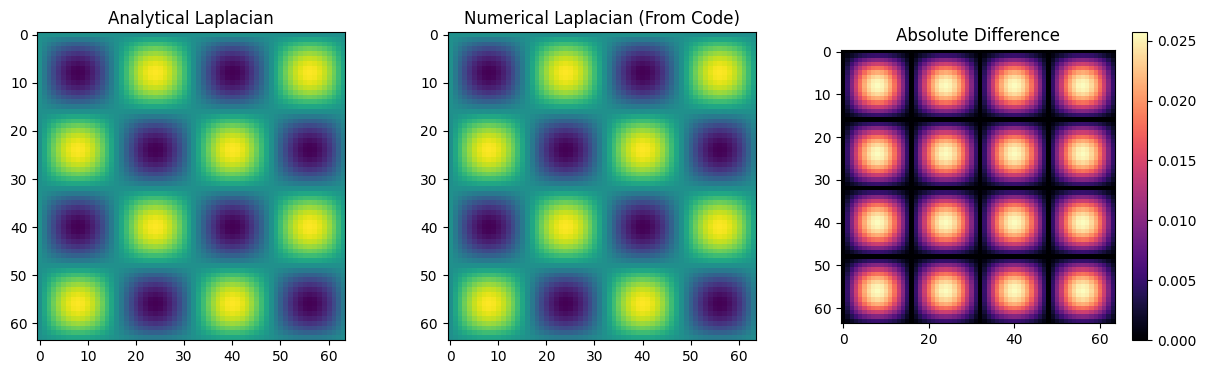

In [ ]:
#Testing that the spatial laplacian works on a simple sin wave dataset.

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

def compute_laplacian(grid, h):
    padded_grid = jnp.pad(grid, ((0, 0), (1, 1), (1, 1)), mode='wrap')
    x = padded_grid.reshape(2, 1, padded_grid.shape[1], padded_grid.shape[2])
    laplacian_kernel = jnp.array([[0.0,  1.0, 0.0],
                                  [1.0, -4.0, 1.0],
                                  [0.0,  1.0, 0.0]], dtype=jnp.float32) / (h ** 2)

    lap = jax.lax.conv(x, laplacian_kernel.reshape(1,1,3,3), window_strides=(1, 1), padding='VALID')
    return lap.squeeze(1)

N = 64
L = 2.0 * jnp.pi
h = L / N
x = jnp.linspace(0, L, N, endpoint=False)
y = jnp.linspace(0, L, N, endpoint=False)
X, Y = jnp.meshgrid(x, y, indexing='ij')
omega = 2.0
V = jnp.sin(omega * X) * jnp.sin(omega * Y)
W = jnp.cos(omega * X) * jnp.cos(omega * Y)

grid = jnp.stack([V, W], axis=0)
analytical_lap_V = -2.0 * (omega**2) * V

numerical_lap = compute_laplacian(grid, h)
numerical_lap_V = numerical_lap[0]
mse = jnp.mean((analytical_lap_V - numerical_lap_V)**2)
print(f"Mean Squared Error between Analytical and Numerical Laplacian: {mse:.6e}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(analytical_lap_V, cmap='viridis')
axes[0].set_title("Analytical Laplacian")
axes[1].imshow(numerical_lap_V, cmap='viridis')
axes[1].set_title("Numerical Laplacian (From Code)")
diff = axes[2].imshow(jnp.abs(analytical_lap_V - numerical_lap_V), cmap='magma')
axes[2].set_title("Absolute Difference")
plt.colorbar(diff, ax=axes[2])
plt.show()

Chaotic Target Trajectory Shape: (30, 2, 100, 100)


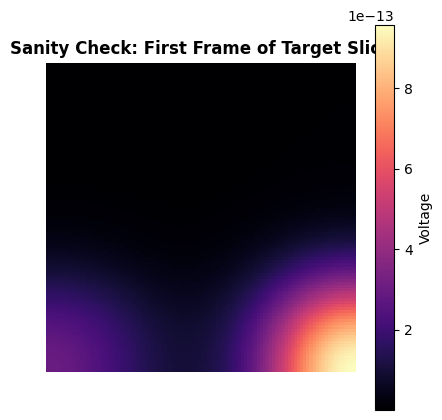

New Target Shape: (30, 2, 100, 100)
Max Voltage in slice: 9.5729e-13


In [ ]:
slice_chaotic = new_train[0, :, 1000:1030, :, :]
target_traj = np.transpose(slice_chaotic, (1, 0, 2, 3))
target_traj_jax = jnp.array(target_traj)
print("Chaotic Target Trajectory Shape:", target_traj_jax.shape)
plt.figure(figsize=(5, 5))
plt.imshow(target_traj_jax[0, 0], cmap='magma')
plt.title("Sanity Check: First Frame of Target Slice", fontweight='bold')
plt.colorbar(label="Voltage")
plt.axis('off')
plt.show()

print("New Target Shape:", target_traj_jax.shape)
print("Max Voltage in slice:", target_traj_jax[:, 0].max())

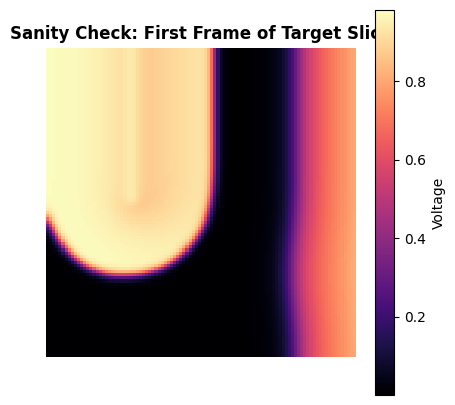

New Target Shape: (40, 2, 100, 100)
Max Voltage in slice: 0.9838684


In [ ]:
import matplotlib.pyplot as plt
import jax.numpy as jnp

deep_slice = new_train[0, :, 460:500, :, :]

# 2. Reshape to (Time, Channel, X, Y) for the ODE
target_traj_jax = jnp.array(deep_slice.transpose(1, 0, 2, 3))

# 3. PROVE it is chaotic before we waste time training
plt.figure(figsize=(5, 5))
plt.imshow(target_traj_jax[0, 0], cmap='magma')
plt.title("Sanity Check: First Frame of Target Slice", fontweight='bold')
plt.colorbar(label="Voltage")
plt.axis('off')
plt.show()

print("New Target Shape:", target_traj_jax.shape)
print("Max Voltage in slice:", target_traj_jax[:, 0].max())

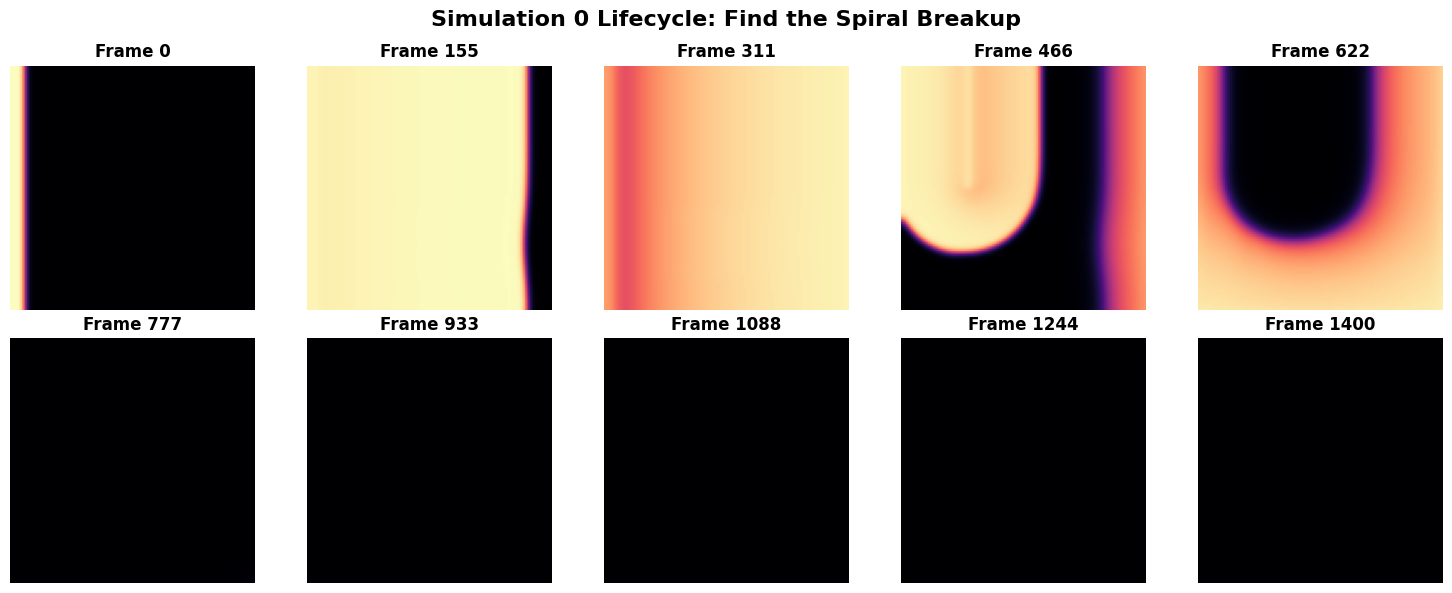

In [ ]:
time_points = np.linspace(0, 1400, 10, dtype=int)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Simulation 0 Lifecycle: Find the Spiral Breakup", fontsize=16, fontweight='bold')
axes = axes.flatten()

for i, t in enumerate(time_points):
    # Grab the Voltage channel (0) at time t
    frame = new_train[0, 0, t, :, :]
    axes[i].imshow(frame, cmap='magma', vmin=0, vmax=1)
    axes[i].set_title(f"Frame {t}", fontweight='bold')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [14]:
import jax
import jax.numpy as jnp
import equinox as eqx
import optax
import diffrax

class ConvODE(eqx.Module):
    layers: list
    def __init__(self, channels=64, key=jax.random.PRNGKey(100)):
        keys = jax.random.split(key, 3)
        self.layers = [
            eqx.nn.Conv2d(channels, channels, kernel_size=3, stride=1, padding=1, key=keys[0]),
            jax.nn.silu,
            eqx.nn.Conv2d(channels, channels, kernel_size=3, stride=1, padding=1, key=keys[1]),
            jax.nn.silu,
            eqx.nn.Conv2d(channels, channels, kernel_size=3, stride=1, padding=1, key=keys[2])
        ]
    def __call__(self, t, z, args):
        for layer in self.layers:
            z = layer(z)
        return z

class LatentNeuralODE(eqx.Module):
    vector_field: ConvODE
    def __init__(self, vector_field):
        self.vector_field = vector_field
    def __call__(self, z0, t_steps):
        term = diffrax.ODETerm(self.vector_field)
        solver = diffrax.Dopri5()
        stepsize_controller = diffrax.PIDController(rtol=1e-2, atol=1e-3)

        sol = diffrax.diffeqsolve(
            term,
            solver,
            t0=t_steps[0],
            t1=t_steps[-1],
            dt0=t_steps[1] - t_steps[0],
            y0=z0,
            stepsize_controller=stepsize_controller,
            saveat=diffrax.SaveAt(ts=t_steps),
            adjoint=diffrax.DirectAdjoint(),
            max_steps=50000
        )
        return sol.ys

In [ ]:


@eqx.filter_value_and_grad
def compute_ode_loss(ode_model, target_seq, encoder, decoder, t_steps):
    x0 = target_seq[0]
    z0 = encoder(x0) # Freeze encoder

    z_pred_traj = ode_model(z0, t_steps)
    x_pred_traj = jax.vmap(decoder)(z_pred_traj) # Freeze decoder

    return jnp.mean((x_pred_traj - target_seq) ** 2)

@eqx.filter_jit
def step_ode(ode_model, opt_state, target_seq, encoder, decoder, t_steps):
    loss, grads = compute_ode_loss(ode_model, target_seq, encoder, decoder, t_steps)
    updates, new_opt_state = optimizer.update(grads, opt_state, ode_model)
    new_ode_model = eqx.apply_updates(ode_model, updates)
    return new_ode_model, new_opt_state, loss

ode_key = jax.random.PRNGKey(100)
latent_ode = LatentNeuralODE(ConvODE(channels=64, key=ode_key))

optimizer = optax.adam(1e-3)
opt_state = optimizer.init(eqx.filter(latent_ode, eqx.is_inexact_array))

t_steps = jnp.arange(40) * 0.2

epochs = 100
print("Starting ODE Training on Chaotic Slice...")

for epoch in range(epochs):
    latent_ode, opt_state, loss = step_ode(
        latent_ode, opt_state, target_traj_jax, trained_encoder, trained_decoder, t_steps
    )

    if epoch % 10 == 0:
        print(f"Epoch {epoch:03d} | ODE MSE Loss: {loss.item():.6f}")

Starting ODE Training on Chaotic Slice...


NameError: name 'target_traj_jax' is not defined

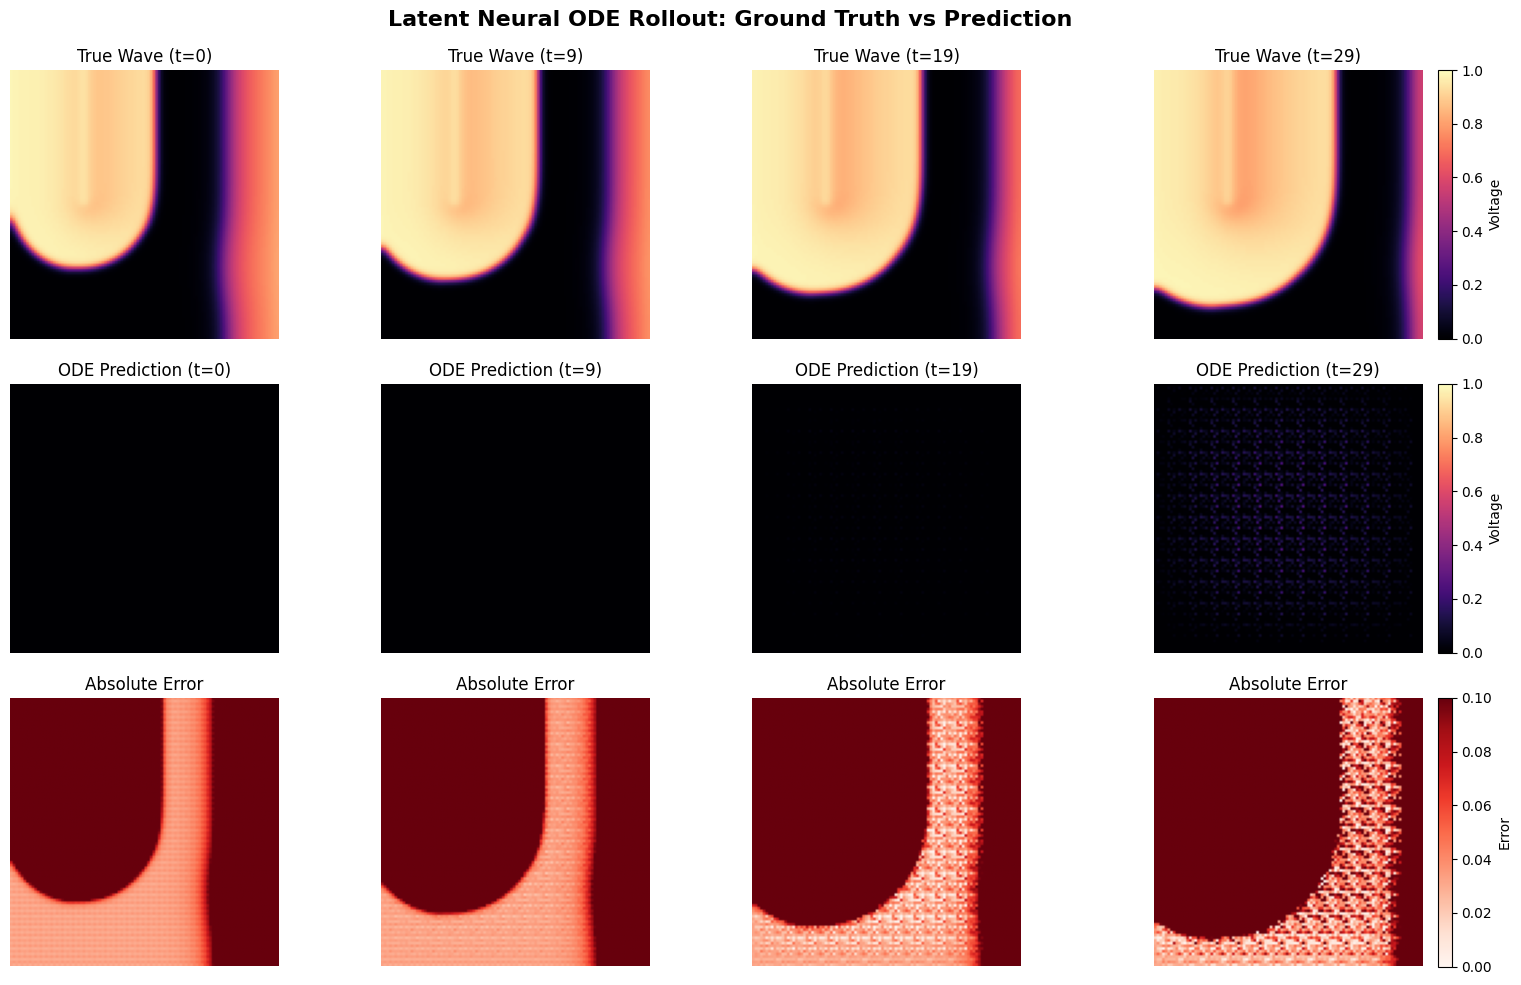

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x0 = target_traj_jax[0]
z0 = trained_encoder(x0)
z_pred_traj = latent_ode(z0, t_steps)
x_pred_traj = jax.vmap(trained_decoder)(z_pred_traj)

true_traj = np.array(target_traj_jax)
pred_traj = np.array(x_pred_traj)

time_indices = [0, 9, 19, 29]
num_cols = len(time_indices)

fig, axes = plt.subplots(3, num_cols, figsize=(16, 10))
fig.suptitle("Latent Neural ODE Rollout: Ground Truth vs Prediction", fontsize=16, fontweight='bold')

for i, t_idx in enumerate(time_indices):
    true_frame = true_traj[t_idx, 0, :, :]
    pred_frame = pred_traj[t_idx, 0, :, :]
    error_frame = np.abs(true_frame - pred_frame)

    im_true = axes[0, i].imshow(true_frame, cmap='magma', vmin=0, vmax=1)
    axes[0, i].set_title(f"True Wave (t={t_idx})")
    axes[0, i].axis('off')

    im_pred = axes[1, i].imshow(pred_frame, cmap='magma', vmin=0, vmax=1)
    axes[1, i].set_title(f"ODE Prediction (t={t_idx})")
    axes[1, i].axis('off')

    im_err = axes[2, i].imshow(error_frame, cmap='Reds', vmin=0, vmax=0.1) # Capped at 10% error for visibility
    axes[2, i].set_title(f"Absolute Error")
    axes[2, i].axis('off')

fig.colorbar(im_true, ax=axes[0, -1], fraction=0.046, pad=0.04, label="Voltage")
fig.colorbar(im_pred, ax=axes[1, -1], fraction=0.046, pad=0.04, label="Voltage")
fig.colorbar(im_err,  ax=axes[2, -1], fraction=0.046, pad=0.04, label="Error")

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

In [ ]:
import optax
import jax

ode_key = jax.random.PRNGKey(42)
latent_ode = LatentNeuralODE(ConvODE(channels=64, key=ode_key))

optimizer = optax.chain(
    optax.clip_by_global_norm(1.0),
    optax.adamw(learning_rate=3e-4)
)

opt_state = optimizer.init(eqx.filter(latent_ode, eqx.is_inexact_array))

epochs = 150
print("Starting Stabilized ODE Training on 40-Step Curling Wave...")

for epoch in range(epochs):
    latent_ode, opt_state, loss = step_ode(
        latent_ode, opt_state, target_traj_jax, trained_encoder, trained_decoder, t_steps
    )

    if epoch % 10 == 0:
        print(f"Epoch {epoch:03d} | ODE MSE Loss: {loss.item():.6f}")

Starting Stabilized ODE Training on 40-Step Curling Wave...
Epoch 000 | ODE MSE Loss: 0.602798
Epoch 010 | ODE MSE Loss: 0.600451
Epoch 020 | ODE MSE Loss: 0.590002
Epoch 030 | ODE MSE Loss: 0.576173
Epoch 040 | ODE MSE Loss: 0.562838
Epoch 050 | ODE MSE Loss: 0.550429
Epoch 060 | ODE MSE Loss: 0.566048
Epoch 070 | ODE MSE Loss: 0.537172
Epoch 080 | ODE MSE Loss: 0.522593
Epoch 090 | ODE MSE Loss: 0.512480
Epoch 100 | ODE MSE Loss: 0.500493
Epoch 110 | ODE MSE Loss: 0.502414


EquinoxRuntimeError: Above is the stack outside of JIT. Below is the stack inside of JIT:
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py", line 37, in <module>
    ColabKernelApp.launch_instance()
  File "/usr/local/lib/python3.12/dist-packages/traitlets/config/application.py", line 992, in launch_instance
    app.start()
  File "/usr/local/lib/python3.12/dist-packages/ipykernel/kernelapp.py", line 712, in start
    self.io_loop.start()
  File "/usr/local/lib/python3.12/dist-packages/tornado/platform/asyncio.py", line 211, in start
    self.asyncio_loop.run_forever()
  File "/usr/lib/python3.12/asyncio/base_events.py", line 645, in run_forever
    self._run_once()
  File "/usr/lib/python3.12/asyncio/base_events.py", line 1999, in _run_once
    handle._run()
  File "/usr/lib/python3.12/asyncio/events.py", line 88, in _run
    self._context.run(self._callback

In [15]:
#####################################
#Preprocess data to train neural ODE#
#####################################

mat_data = scipy.io.loadmat(dataset_path + "spiral_data_001.mat")
V = np.transpose(mat_data['Vsav'], (2, 0, 1))
W = np.transpose(mat_data['Wsav'], (2, 0, 1))
full_dataset = jnp.array(np.stack([V, W], axis=1))
tend = mat_data['tend'].item()
dt_matlab = mat_data['dt'].item()
h = mat_data['h'].item()
num_frames = full_dataset.shape[0]
time_array = jnp.linspace(0, tend, num_frames)
a = mat_data['a'].item()
b = mat_data['b'].item()
k = mat_data['k'].item()
epsi = mat_data['epsi'].item()
mu1 = mat_data['mu1'].item()
mu2 = mat_data['mu2'].item()

# Extract the diffusion matrices
D = jnp.array(mat_data['D'])       # Shape (102, 102) - MATLAB likely padded the boundaries
Dfac = mat_data['Dfac'].item()     # The fibrosis multiplier we discussed!

print(f"Dataset shape: {full_dataset.shape}")
print(f"Time array shape: {time_array.shape}")
print(f"Physical Constants Loaded: a={a}, k={k}, h={h}")

Dataset shape: (1496, 2, 100, 100)
Time array shape: (1496,)
Physical Constants Loaded: a=0.05, k=8, h=0.25


In [16]:
import jax
import jax.numpy as jnp
import equinox as eqx
from diffrax import diffeqsolve, ODETerm, Kvaerno5, SaveAt, PIDController

def create_chunks(dataset, chunk_length=40):
    """
    Slices the (1496, C, H, W) dataset into contiguous, non-overlapping chunks.
    Ensures the very last segment is included by slightly overlapping it if necessary.
    """
    total_frames = dataset.shape[0]
    stride = chunk_length  # No overlap

    # Calculate how many full chunks we can fit
    num_chunks = total_frames // stride

    chunks = []

    for i in range(num_chunks):
        start_idx = i * stride
        end_idx = start_idx + chunk_length
        chunks.append(dataset[start_idx:end_idx])

    # Handle the leftover frames at the end
    if total_frames % stride != 0:
        # Start exactly chunk_length away from the end to maintain shape
        start_idx = total_frames - chunk_length
        end_idx = total_frames
        chunks.append(dataset[start_idx:end_idx])

    # Shape: (num_chunks, chunk_length, 2, 100, 100)
    return jnp.stack(chunks)

@eqx.filter_value_and_grad
def chunked_loss(encoder, decoder, ode_func, chunks, dt):
    """
    encoder: The trained encoder model.
    decoder: The trained decoder model.
    ode_func: The vector field of the latent ODE.
    chunks: (batch, chunk_length, C, H, W)
    dt: The time step for integration.
    """

    # Extract dimensions
    batch_size, chunk_length, _, _, _ = chunks.shape

    # Create the relative time array for a single chunk [0.0, dt, 2*dt...]
    t_eval = jnp.linspace(0.0, (chunk_length - 1) * dt, chunk_length)

    # 1. Extract the ground-truth starting frame for every chunk
    # Shape: (batch, C, H, W)
    V_starts = chunks[:, 0]

    # 2. Encode all starting frames into Latent Space simultaneously
    # Shape: (batch, latent_dim)
    z0_batched = jax.vmap(encoder)(V_starts)

    # 3. Define the integration for a single chunk
    def integrate_single_chunk(z0):
        term = ODETerm(ode_func)
        solver = Kvaerno5()
        stepsize_controller = PIDController(rtol=1e-3, atol=1e-3)
        saveat = SaveAt(ts=t_eval)

        sol = diffeqsolve(
            term, solver, t0=t_eval[0], t1=t_eval[-1], dt0=dt,
            y0=z0, stepsize_controller=stepsize_controller, saveat=saveat
        )
        return sol.ys # Shape: (chunk_length, latent_dim)

    # 4. Integrate all chunks in parallel using jax.vmap
    # Shape: (batch, chunk_length, C_lat, H_lat, W_lat)
    z_pred_batched = jax.vmap(integrate_single_chunk)(z0_batched)

    # 5. Decode the full latent trajectories
    # Dynamically extract the latent spatial shape
    batch_size = z_pred_batched.shape[0]
    chunk_length = z_pred_batched.shape[1]
    latent_shape = z_pred_batched.shape[2:] # Grabs (C_lat, H_lat, W_lat)

    # Flatten the batch and time dimensions to pass through decoder
    z_flat = z_pred_batched.reshape(batch_size * chunk_length, *latent_shape)

    V_pred_flat = jax.vmap(decoder)(z_flat)
    V_pred_batched = V_pred_flat.reshape(batch_size, chunk_length, 2, 100, 100)

    # 6. Calculate standard Data Loss (MSE against ground truth)
    data_loss = jnp.mean((V_pred_batched - chunks) ** 2)

    return data_loss

In [17]:
# Call the function using your actual variable 'full_dataset'
chunked_data = create_chunks(full_dataset, chunk_length=40)

print(f"Original full_dataset shape: {full_dataset.shape}")
print(f"Chunked data shape: {chunked_data.shape}")

Original full_dataset shape: (1496, 2, 100, 100)
Chunked data shape: (38, 40, 2, 100, 100)


In [18]:
import optax
import diffrax
from diffrax import ODETerm, Dopri5, PIDController, SaveAt, diffeqsolve

# 1. Redefine chunked_loss with ode_func as the FIRST argument for correct gradients
@eqx.filter_value_and_grad
def chunked_loss(ode_func, encoder, decoder, chunks, dt):
    batch_size, chunk_length, _, _, _ = chunks.shape
    t_eval = jnp.linspace(0.0, (chunk_length - 1) * dt, chunk_length)

    V_starts = chunks[:, 0]
    z0_batched = jax.vmap(encoder)(V_starts)

    def integrate_single_chunk(z0):
        term = ODETerm(ode_func)
        solver = Dopri5()  # Switched to explicit solver for massive speedup
        stepsize_controller = PIDController(rtol=1e-2, atol=1e-2) # Relaxed tolerances
        saveat = SaveAt(ts=t_eval)

        sol = diffeqsolve(
            term, solver, t0=t_eval[0], t1=t_eval[-1], dt0=dt,
            y0=z0, stepsize_controller=stepsize_controller, saveat=saveat,
            adjoint=diffrax.RecursiveCheckpointAdjoint() # Memory efficient backprop
        )
        return sol.ys

    z_pred_batched = jax.vmap(integrate_single_chunk)(z0_batched)

    batch_size, chunk_length = z_pred_batched.shape[:2]
    latent_shape = z_pred_batched.shape[2:]

    z_flat = z_pred_batched.reshape(batch_size * chunk_length, *latent_shape)
    V_pred_flat = jax.vmap(decoder)(z_flat)
    V_pred_batched = V_pred_flat.reshape(batch_size, chunk_length, 2, 100, 100)

    return jnp.mean((V_pred_batched - chunks) ** 2)

# 2. Define the training step
@eqx.filter_jit
def train_step(ode_func, opt_state, encoder, decoder, chunks, dt):
    loss, grads = chunked_loss(ode_func, encoder, decoder, chunks, dt)
    updates, new_opt_state = optimizer.update(grads, opt_state, ode_func)
    new_ode_func = eqx.apply_updates(ode_func, updates)
    return new_ode_func, new_opt_state, loss

# 3. Setup Optimizer and initialize ODE Model (Vector Field)
ode_key = jax.random.PRNGKey(42)
ode_func = ConvODE(channels=64, key=ode_key)

optimizer = optax.chain(
    optax.clip_by_global_norm(1.0),
    optax.adamw(learning_rate=1e-3)
)
opt_state = optimizer.init(eqx.filter(ode_func, eqx.is_array))

# Optional: If memory issues occur, you can slice train_chunks (e.g., chunked_data[:10])
train_chunks = chunked_data

In [ ]:
# 4. Training Loop
epochs = 50
batch_size = 1  # Minimum batch size to prevent OOM

print(f"Starting chunked ODE training on {train_chunks.shape[0]} chunks with batch size {batch_size}...")

for epoch in range(epochs):
    epoch_loss = 0.0
    num_batches = 0

    for i in range(0, train_chunks.shape[0], batch_size):
        batch = train_chunks[i:i+batch_size]
        ode_func, opt_state, loss = train_step(
            ode_func, opt_state, trained_encoder, trained_decoder, batch, dt_matlab
        )
        epoch_loss += loss.item()
        num_batches += 1

    avg_loss = epoch_loss / num_batches

    if epoch % 5 == 0:
        print(f"Epoch {epoch:03d} | Chunked ODE Avg MSE Loss: {avg_loss:.6f}")

Starting chunked ODE training on 38 chunks with batch size 1...
Epoch 000 | Chunked ODE Avg MSE Loss: 0.034198
Epoch 005 | Chunked ODE Avg MSE Loss: 0.012606
Epoch 010 | Chunked ODE Avg MSE Loss: 0.009849
Epoch 015 | Chunked ODE Avg MSE Loss: 0.010104
Epoch 020 | Chunked ODE Avg MSE Loss: 0.006812
Epoch 025 | Chunked ODE Avg MSE Loss: 0.006026
Epoch 030 | Chunked ODE Avg MSE Loss: 0.006836
Epoch 035 | Chunked ODE Avg MSE Loss: 0.003809
Epoch 040 | Chunked ODE Avg MSE Loss: 0.004330
Epoch 045 | Chunked ODE Avg MSE Loss: 0.004482


In [19]:
ode_save_path = dataset_path + "trained_ode_func.eqx"


In [ ]:
import equinox as eqx
import jax


# 1. Serialize (Save) the trained ODE vector field
print(f"Saving trained ODE model to {ode_save_path}...")
eqx.tree_serialise_leaves(ode_save_path, ode_func)

# 2. Deserialize (Load) the trained ODE vector field
# First, create an uninitialized "skeleton" of the exact same model architecture


Saving trained ODE model to /content/drive/MyDrive/ap_dataset/trained_ode_func.eqx...


In [20]:
empty_ode_key = jax.random.PRNGKey(0)
empty_ode_skeleton = ConvODE(channels=64, key=empty_ode_key)

# Then, populate the skeleton with the saved weights
print("Loading model from saved file...")
loaded_ode_func = eqx.tree_deserialise_leaves(ode_save_path, empty_ode_skeleton)

print("Model successfully saved and loaded!")

Loading model from saved file...
Model successfully saved and loaded!


In [26]:
import jax
import jax.numpy as jnp
import equinox as eqx
from diffrax import diffeqsolve, ODETerm, Kvaerno5, SaveAt, PIDController
import matplotlib.pyplot as plt

@eqx.filter_jit
def rollout_model(ode_func, encoder, decoder, initial_frame, dt, num_steps):
    """
    Takes a single initial frame, encodes it, and integrates it continuously
    for `num_steps` without any multiple shooting interventions.
    """
    # 1. Encode the initial frame into latent space
    z0 = encoder(initial_frame)

    # 2. Set up the evaluation time steps
    # We want to unroll for num_steps, saving at each step
    t_eval = jnp.linspace(0.0, (num_steps - 1) * dt, num_steps)

    # 3. Configure the ODE Solver
    term = ODETerm(ode_func)
    solver = Kvaerno5()
    stepsize_controller = PIDController(rtol=1e-3, atol=1e-3)
    saveat = SaveAt(ts=t_eval)

    # 4. Integrate continuously over the long horizon
    sol = diffeqsolve(
        term, solver, t0=t_eval[0], t1=t_eval[-1], dt0=dt,
        y0=z0, stepsize_controller=stepsize_controller, saveat=saveat
    )

    # 5. Decode the predicted latent trajectory back to pixel space
    # sol.ys shape will be (num_steps, *latent_shape)
    z_pred = sol.ys
    V_pred = jax.vmap(decoder)(z_pred)

    return V_pred

def plot_rollout(gt_trajectory, pred_trajectory, frame_indices, save_path="rollout_comparison.png"):
    """
    Plots the Ground Truth vs Predicted voltage (channel 0) side-by-side.
    gt_trajectory: (T, 2, 100, 100)
    pred_trajectory: (T, 2, 100, 100)
    frame_indices: List of time indices to plot (e.g., [0, 50, 100, 150, 200])
    """
    num_frames = len(frame_indices)
    fig, axes = plt.subplots(2, num_frames, figsize=(3 * num_frames, 6))

    for i, t_idx in enumerate(frame_indices):
        # We assume channel 0 is the Voltage (v) variable
        gt_frame = gt_trajectory[t_idx, 0, :, :]
        pred_frame = pred_trajectory[t_idx, 0, :, :]

        # Plot Ground Truth
        ax_gt = axes[0, i]
        im_gt = ax_gt.imshow(gt_frame, cmap='magma', vmin=0.0, vmax=1.0)
        ax_gt.set_title(f"GT (t={t_idx})")
        ax_gt.axis('off')

        # Plot Prediction
        ax_pred = axes[1, i]
        im_pred = ax_pred.imshow(pred_frame, cmap='magma', vmin=0.0, vmax=1.0)
        ax_pred.set_title(f"Pred (t={t_idx})")
        ax_pred.axis('off')

    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()
    print(f"Saved rollout visualization to {save_path}")

def evaluate_baseline(ode_func, encoder, decoder, dataset, dt=0.05, steps_to_simulate=300):
    """
    Wrapper to execute the rollout and generate the Figure 1 plot.
    """
    print(f"Starting long-horizon rollout for {steps_to_simulate} steps...")

    # 1. Grab the very first frame to start the simulation
    initial_frame = dataset[0]

    # 2. Get the ground truth trajectory (for comparison)
    gt_trajectory = dataset[:steps_to_simulate]

    # 3. Generate the continuous prediction
    pred_trajectory = rollout_model(ode_func, encoder, decoder, initial_frame, dt, steps_to_simulate)

    # 4. Calculate global MSE over time to see where it blows up
    mse_over_time = jnp.mean((pred_trajectory - gt_trajectory)**2, axis=(1, 2, 3))
    print(f"Final MSE at t={steps_to_simulate}: {mse_over_time[-1]:.6f}")

    # 5. Pick specific frames to plot (e.g., start, middle, end)
    # Adjust these indices based on how long your sequence is
    frames_to_plot = [0, steps_to_simulate // 4, steps_to_simulate // 2, (3 * steps_to_simulate) // 4, steps_to_simulate - 1]

    # 6. Generate the plot
    plot_rollout(gt_trajectory, pred_trajectory, frames_to_plot)

    return mse_over_time

# Example of how you would call this after your training loop finishes:
# mse_history = evaluate_baseline(trained_ode_func, encoder, decoder, dataset, dt=0.05, steps_to_simulate=400)

In [ ]:
mse_history = evaluate_baseline(
    ode_func=loaded_ode_func,
    encoder=trained_encoder,
    decoder=trained_decoder,
    dataset=full_dataset,
    dt=dt_matlab,
    steps_to_simulate=400
)

plt.figure(figsize=(10, 5))
plt.plot(mse_history, label='MSE vs Time')
plt.xlabel('Time Step')
plt.ylabel('Mean Squared Error')
plt.title('Error Growth Over Continuous Rollout')
plt.legend()
plt.yscale('log')
plt.show()

Loading unseen test data from: /content/drive/MyDrive/ap_dataset/spiral_data_091.mat
Test File Dfac (Fibrosis multiplier): 0.8614
Test File epsi: 0.0020
Starting long-horizon rollout for 400 steps...
Final MSE at t=400: 0.630844


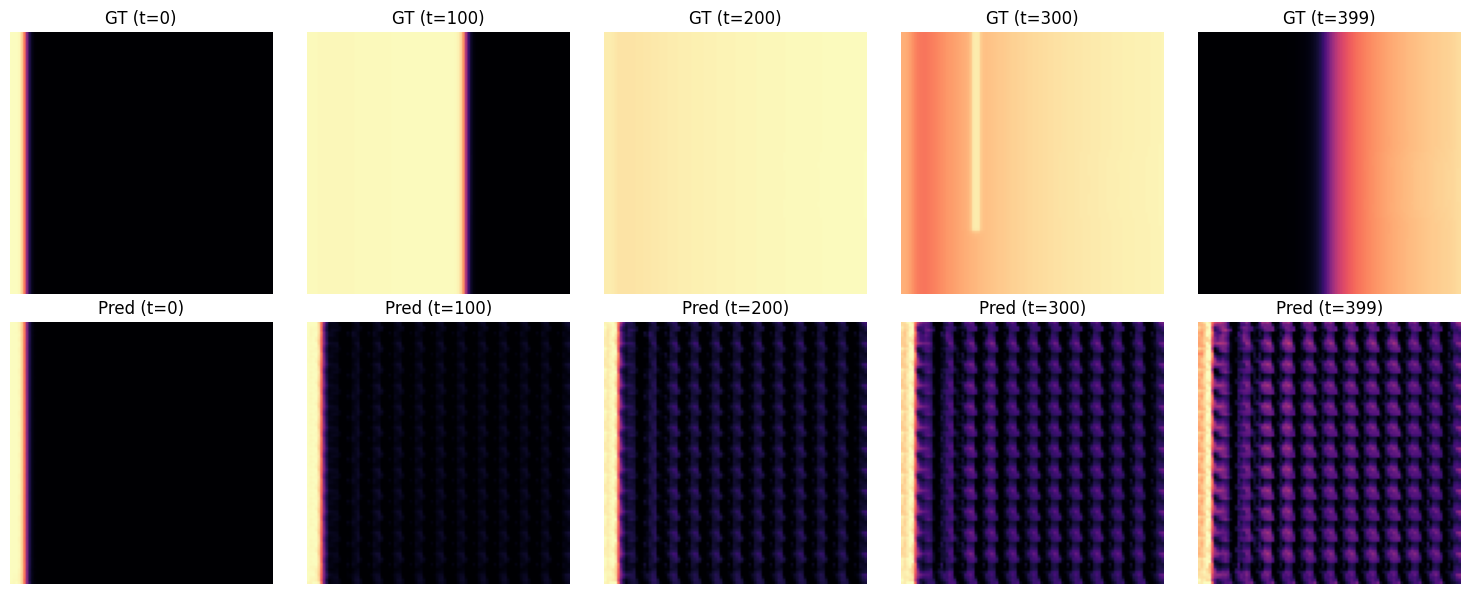

Saved rollout visualization to rollout_comparison.png


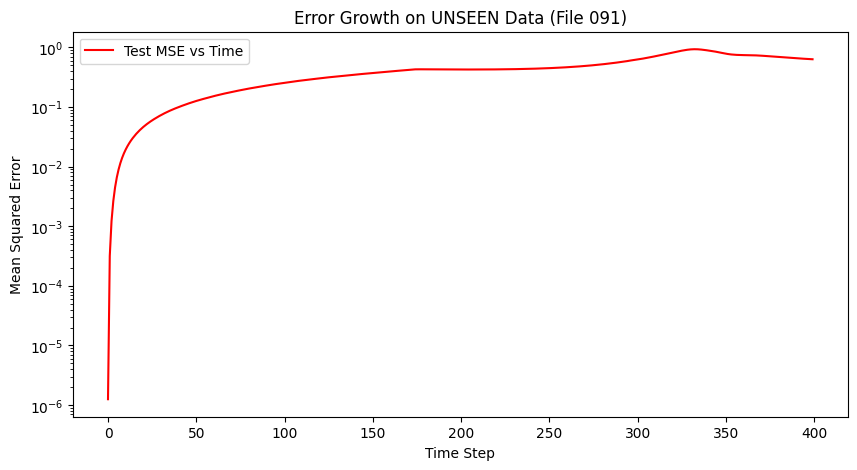

In [ ]:
import scipy.io
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

# 1. Load an unseen test file (e.g., file 91 from your test split)
test_file_path = dataset_path + "spiral_data_091.mat"
print(f"Loading unseen test data from: {test_file_path}")
test_mat_data = scipy.io.loadmat(test_file_path)

# 2. Extract and format the spatial data
V_test = np.transpose(test_mat_data['Vsav'], (2, 0, 1))
W_test = np.transpose(test_mat_data['Wsav'], (2, 0, 1))
unseen_dataset = jnp.array(np.stack([V_test, W_test], axis=1))

# Let's peek at some parameters to see what makes this file unique!
print(f"Test File Dfac (Fibrosis multiplier): {test_mat_data['Dfac'].item():.4f}")
print(f"Test File epsi: {test_mat_data['epsi'].item():.4f}")

# 3. Evaluate the baseline on this completely unseen trajectory
test_mse_history = evaluate_baseline(
    ode_func=loaded_ode_func,
    encoder=trained_encoder,
    decoder=trained_decoder,
    dataset=unseen_dataset,
    dt=dt_matlab,
    steps_to_simulate=400
)

# 4. Plot the error growth for the unseen data
plt.figure(figsize=(10, 5))
plt.plot(test_mse_history, label='Test MSE vs Time', color='red')
plt.xlabel('Time Step')
plt.ylabel('Mean Squared Error')
plt.title('Error Growth on UNSEEN Data (File 091)')
plt.legend()
plt.yscale('log')
plt.show()

### Multiple Shooting Augmented Lagrangian (ALMS) Training
Now we will train the Neural ODE using ALMS to encourage continuity across longer trajectories.

In [21]:
# 1. Grab metadata from the first file to keep dt_matlab
mat_data = scipy.io.loadmat(dataset_path + "spiral_data_001.mat")
dt_matlab = mat_data['dt'].item()
print(f"Loaded dt_matlab: {dt_matlab}")

# 2. Add our new Dataset functions directly into the notebook
def create_file_coherent_chunks(dataset, chunk_length=40):
    num_files, total_frames, channels, h, w = dataset.shape
    stride = chunk_length
    num_chunks_per_file = total_frames // stride

    all_file_chunks = []
    for file_idx in range(num_files):
        file_data = dataset[file_idx]
        file_chunks = []
        for i in range(num_chunks_per_file):
            start_idx = i * stride
            end_idx = start_idx + chunk_length
            file_chunks.append(file_data[start_idx:end_idx])
        all_file_chunks.append(np.stack(file_chunks))
    return jnp.stack(all_file_chunks)

def sample_alms_batch(file_coherent_chunks, batch_size=4, window_size=6):
    num_files, num_chunks, chunk_len, c, h, w = file_coherent_chunks.shape
    file_indices = np.random.choice(num_files, size=batch_size, replace=False)
    max_start_idx = num_chunks - window_size

    batch_windows = []
    for f_idx in file_indices:
        start_chunk_idx = np.random.randint(0, max_start_idx + 1)
        end_chunk_idx = start_chunk_idx + window_size
        window = file_coherent_chunks[f_idx, start_chunk_idx:end_chunk_idx]
        batch_windows.append(window)
    return jnp.stack(batch_windows)

# 3. Use the already loaded `new_train` data!
# new_train is (80, 2, 1496, 100, 100), we transpose to (80, 1496, 2, 100, 100)
print("Reusing already loaded `new_train` array...")
train_dataset_multi = new_train.transpose(0, 2, 1, 3, 4)
print(f"Multi-file Dataset shape: {train_dataset_multi.shape}")

train_chunks_coherent = create_file_coherent_chunks(train_dataset_multi, chunk_length=40)
print(f"Coherent Chunks shape: {train_chunks_coherent.shape}")

Loaded dt_matlab: 0.05
Reusing already loaded `new_train` array...
Multi-file Dataset shape: (80, 1496, 2, 100, 100)
Coherent Chunks shape: (80, 37, 40, 2, 100, 100)


In [22]:
import optax
import diffrax
from diffrax import ODETerm, Dopri5, PIDController, SaveAt, diffeqsolve

# 1. The Inner Loss Function (Processes 1 File / 1 Window)
def single_file_loss(ode_func, encoder, decoder, file_window, dt):
    # file_window shape: (window_size, chunk_length, 2, 100, 100)
    window_size, chunk_length, _, _, _ = file_window.shape
    t_eval = jnp.linspace(0.0, (chunk_length - 1) * dt, chunk_length)

    # A. Get initial conditions and encode them
    V_starts = file_window[:, 0]
    z0_array = jax.vmap(encoder)(V_starts)

    # B. Define integration for ONE chunk
    def integrate_single_chunk(z0):
        term = ODETerm(ode_func)
        solver = Dopri5()
        stepsize_controller = PIDController(rtol=1e-2, atol=1e-2)
        saveat = SaveAt(ts=t_eval)

        sol = diffeqsolve(
            term, solver, t0=t_eval[0], t1=t_eval[-1], dt0=dt,
            y0=z0, stepsize_controller=stepsize_controller, saveat=saveat,
            adjoint=diffrax.RecursiveCheckpointAdjoint()
        )
        return sol.ys # Shape: (chunk_length, latent_dim)

    # C. VMAP across the chunks in this window!
    z_pred_window = jax.vmap(integrate_single_chunk)(z0_array)

    # D. Decode predictions
    latent_shape = z_pred_window.shape[2:]
    z_flat = z_pred_window.reshape(window_size * chunk_length, *latent_shape)
    V_pred_flat = jax.vmap(decoder)(z_flat)
    V_pred_window = V_pred_flat.reshape(window_size, chunk_length, 2, 100, 100)

    # E. Calculate Standard Data Loss
    data_loss = jnp.mean((V_pred_window - file_window) ** 2)

    # F. Calculate ALMS Continuity Defect!
    # Compare END of chunk i with START of chunk i+1
    defects = z_pred_window[:-1, -1, :] - z0_array[1:, :]
    defect_loss = jnp.mean(defects ** 2)

    # Return combined loss (we use mu=1.0 for the penalty for now)
    return data_loss + 1.0 * defect_loss

# 2. The Outer Loss Function (VMAP across the 4 Files in the batch)
@eqx.filter_value_and_grad
def batched_loss(ode_func, encoder, decoder, batch_windows, dt):
    # batch_windows shape: (batch_size, window_size, chunk_length, 2, 100, 100)
    # in_axes specifies that ONLY batch_windows gets sliced along axis 0.
    # Everything else (ode_func, encoder, etc.) is cloned into the parallel tunnels.
    batch_loss_fn = jax.vmap(single_file_loss, in_axes=(None, None, None, 0, None))

    # This returns an array of losses (one for each file)
    losses = batch_loss_fn(ode_func, encoder, decoder, batch_windows, dt)
    return jnp.mean(losses)

# 3. Define the training step
@eqx.filter_jit
def train_step_alms(ode_func, opt_state, encoder, decoder, batch_windows, dt):
    loss, grads = batched_loss(ode_func, encoder, decoder, batch_windows, dt)
    updates, new_opt_state = alms_optimizer.update(grads, opt_state, ode_func)
    new_ode_func = eqx.apply_updates(ode_func, updates)
    return new_ode_func, new_opt_state, loss

In [25]:
# 4. Setup Optimizer and initialize ODE Model
alms_ode_key = jax.random.PRNGKey(42)
alms_ode_func = ConvODE(channels=64, key=alms_ode_key)

alms_optimizer = optax.chain(
    optax.clip_by_global_norm(1.0),
    optax.adamw(learning_rate=1e-3)
)
alms_opt_state = alms_optimizer.init(eqx.filter(alms_ode_func, eqx.is_array))

# 5. Sliding Window Training Loop
epochs = 50
batch_size = 4    # Process 4 files at a time
window_size = 6   # Process 6 chronological chunks per file
steps_per_epoch = 20 # Number of sliding window samples per epoch

print(f"Starting ALMS training on {train_chunks_coherent.shape[0]} files...")
print(f"Batch settings: {batch_size} files/batch, {window_size} chunks/window.")

for epoch in range(epochs):
    epoch_loss = 0.0

    for step in range(steps_per_epoch):
        # Sample a fresh batch of sliding windows!
        batch_windows = sample_alms_batch(train_chunks_coherent, batch_size=batch_size, window_size=window_size)

        alms_ode_func, alms_opt_state, loss = train_step_alms(
            alms_ode_func, alms_opt_state, trained_encoder, trained_decoder, batch_windows, dt_matlab
        )
        epoch_loss += loss.item()

    avg_loss = epoch_loss / steps_per_epoch

    if epoch % 5 == 0:
        print(f"Epoch {epoch:03d} | ALMS Sliding Window Avg Loss: {avg_loss:.6f}")

Starting ALMS training on 80 files...
Batch settings: 4 files/batch, 6 chunks/window.
Epoch 000 | ALMS Sliding Window Avg Loss: 0.281141
Epoch 005 | ALMS Sliding Window Avg Loss: 0.198725
Epoch 010 | ALMS Sliding Window Avg Loss: 0.273096
Epoch 015 | ALMS Sliding Window Avg Loss: 0.214924
Epoch 020 | ALMS Sliding Window Avg Loss: 0.241826
Epoch 025 | ALMS Sliding Window Avg Loss: 0.219224
Epoch 030 | ALMS Sliding Window Avg Loss: 0.174086
Epoch 035 | ALMS Sliding Window Avg Loss: 0.270483
Epoch 040 | ALMS Sliding Window Avg Loss: 0.239330
Epoch 045 | ALMS Sliding Window Avg Loss: 0.211223


Loading unseen test data from: /content/drive/MyDrive/ap_dataset/spiral_data_091.mat
Test File Dfac (Fibrosis multiplier): 0.8614
Test File epsi: 0.0020
Starting long-horizon rollout for 400 steps...
Final MSE at t=400: 0.701818


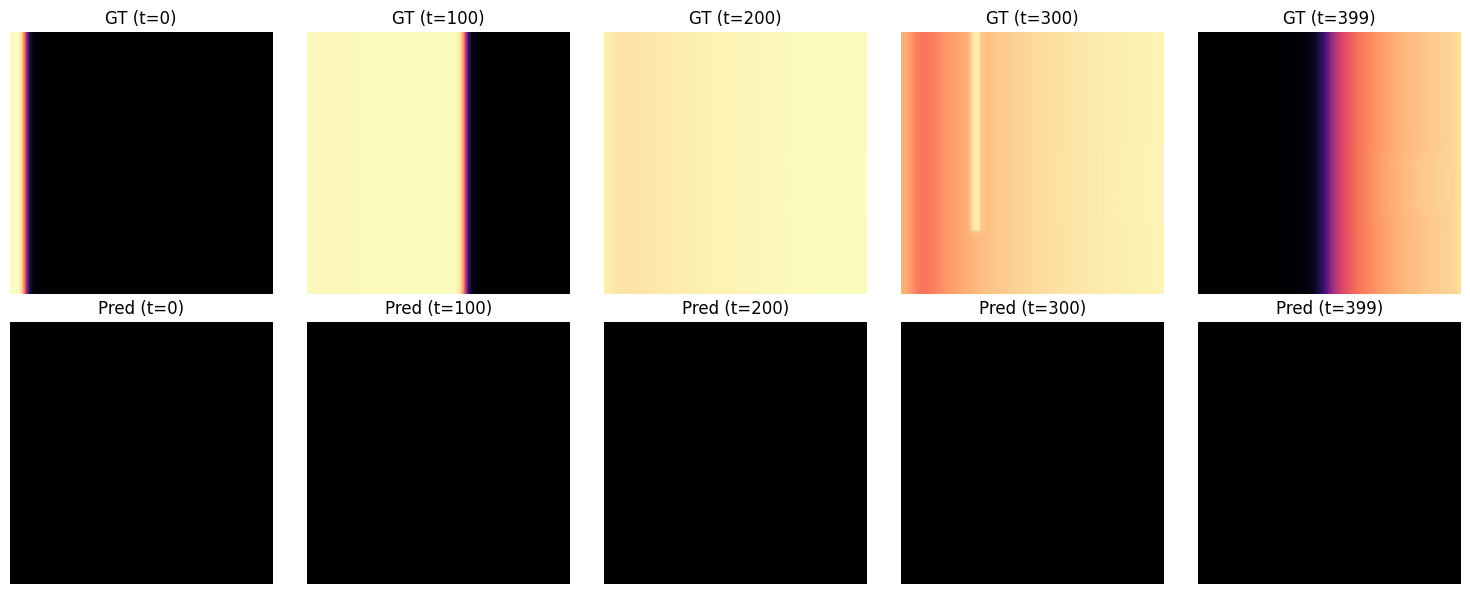

Saved rollout visualization to rollout_comparison.png


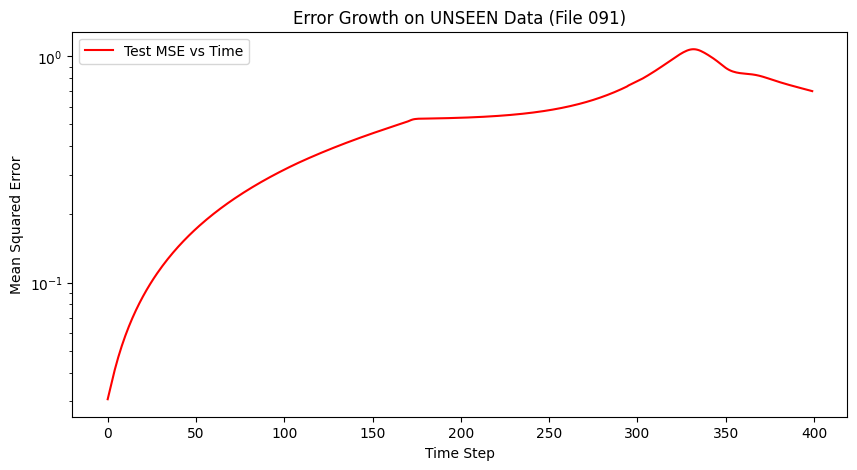

In [28]:
import scipy.io
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

# 1. Load an unseen test file (e.g., file 91 from your test split)
test_file_path = dataset_path + "spiral_data_091.mat"
print(f"Loading unseen test data from: {test_file_path}")
test_mat_data = scipy.io.loadmat(test_file_path)

# 2. Extract and format the spatial data
V_test = np.transpose(test_mat_data['Vsav'], (2, 0, 1))
W_test = np.transpose(test_mat_data['Wsav'], (2, 0, 1))
unseen_dataset = jnp.array(np.stack([V_test, W_test], axis=1))

# Let's peek at some parameters to see what makes this file unique!
print(f"Test File Dfac (Fibrosis multiplier): {test_mat_data['Dfac'].item():.4f}")
print(f"Test File epsi: {test_mat_data['epsi'].item():.4f}")

# 3. Evaluate the baseline on this completely unseen trajectory
test_mse_history = evaluate_baseline(
    ode_func=alms_ode_func,
    encoder=trained_encoder,
    decoder=trained_decoder,
    dataset=unseen_dataset,
    dt=dt_matlab,
    steps_to_simulate=400
)

# 4. Plot the error growth for the unseen data
plt.figure(figsize=(10, 5))
plt.plot(test_mse_history, label='Test MSE vs Time', color='red')
plt.xlabel('Time Step')
plt.ylabel('Mean Squared Error')
plt.title('Error Growth on UNSEEN Data (File 091)')
plt.legend()
plt.yscale('log')
plt.show()

In [30]:
# Recalculate pred_trajectory since it was a local variable inside evaluate_baseline
initial_frame = unseen_dataset[0]
pred_trajectory = rollout_model(
    alms_ode_func,
    trained_encoder,
    trained_decoder,
    initial_frame,
    dt_matlab,
    num_steps=400
)

print(f"Max: {jnp.max(pred_trajectory)}, Min: {jnp.min(pred_trajectory)}, NaNs: {jnp.isnan(pred_trajectory).any()}")

Max: -0.01030040718615055, Min: -0.041806526482105255, NaNs: False
